## Import

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [3]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [4]:
pre_path = "../../../../../../../"
physical_model = "PARSEC"
path_to_data = pre_path + "data/PARSEC/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "scale_power"
output_parameters = ['mass', 'radius']
categories_name = ["label"]

In [5]:
override = True
use_preds = False
save = True
show = True
scaler_name = "power"

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading PARSEC dataframe from PARSEC_rescaled_iso_full_data.csv file...


,logAge,logTe,logg,label,metallicity,Mass,Rpol
0,5.00000,3.4744,2.965,0.0,-0.25,0.090,0.213783
1,5.00000,3.4752,2.963,0.0,-0.25,0.092,0.219060
2,5.00000,3.4780,2.956,0.0,-0.25,0.098,0.236789
3,5.00000,3.4789,2.954,0.0,-0.25,0.100,0.242293
4,5.00000,3.4819,2.950,0.0,-0.25,0.106,0.257918
...,...,...,...,...,...,...,...
681298,10.25002,3.4812,0.032,7.0,0.50,0.801,2.156549
681299,10.25002,3.4776,-0.004,7.0,0.50,0.801,2.175802
681300,10.25002,3.4742,-0.038,7.0,0.50,0.800,2.194514
681301,10.25002,3.4701,-0.077,7.0,0.50,0.800,2.215902


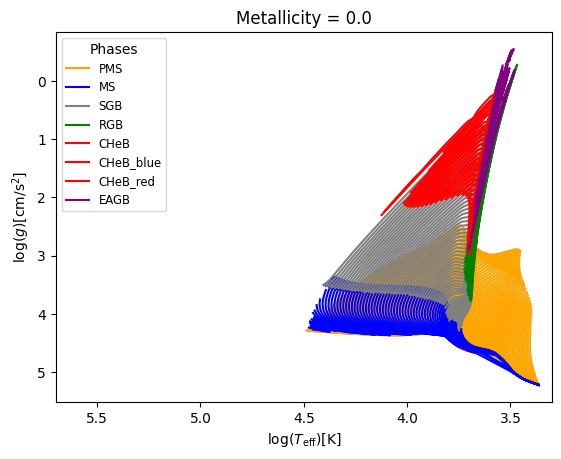

In [6]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['logAge', 'logTe', 'logg', 'label', 'metallicity', 'Mass', 'Rpol'], 
                              physical_model, rescale=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,logAge,logTe,logg,label,metallicity,Mass,Rpol
0,5.60000,4.4269,4.356,1.0,-0.25,9.714,0.535041
1,5.65000,4.4266,4.355,1.0,-0.25,9.714,0.535800
2,5.70000,4.4263,4.353,1.0,-0.25,9.714,0.536558
3,5.75000,4.4061,4.358,1.0,-0.25,8.856,0.514282
4,5.75000,4.4260,4.352,1.0,-0.25,9.714,0.537441
...,...,...,...,...,...,...,...
321691,10.25002,3.6561,2.334,4.0,0.50,0.805,1.005181
321692,10.25002,3.6560,2.333,4.0,0.50,0.805,1.005609
321693,10.25002,3.6559,2.331,4.0,0.50,0.805,1.006466
321694,10.25002,3.6558,2.330,4.0,0.50,0.805,1.006894


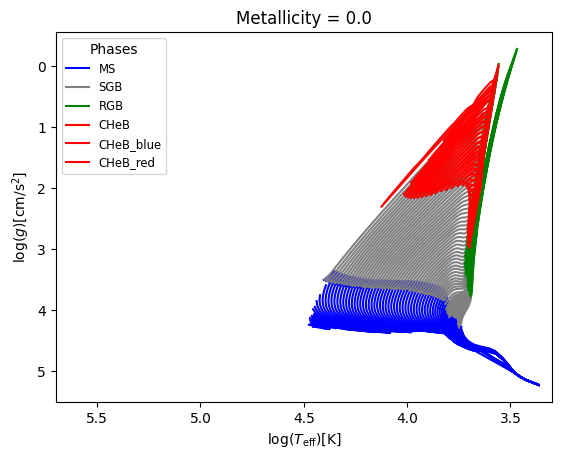

In [7]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'label':[1, 2, 3, 4, 5, 6]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [8]:
print_all_uniques(phase_filtered_iso_df)

logAge  : Range : 5.3 - 10.25, Mean : 9.0428, Median : 9.3

logTe  : Range : 3.36 - 4.5177, Mean : 3.7779, Median : 3.721

logg  : Range : -0.38 - 5.345, Mean : 2.7607, Median : 2.486

Values in label column : 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.25, -2.5, -2.75, 0.0, 0.25, 0.5 

Mass  : Range : 0.09 - 13.952, Mean : 2.6725, Median : 1.428

Rpol  : Range : -0.98 - 2.8373, Mean : 0.9648, Median : 1.0158



In [9]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['logAge', 'logTe', 'logg', 'metallicity'], 
                               y_cols=['Mass', 'Rpol'], categories_cols=['label'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the Mass parameter : 0.09 - 13.943
Median value in train data for the Mass parameter: 1.427
Mean value in train data for the Mass parameter: 2.674483292715276

Range in train data for the Rpol parameter : -0.9763360818022064 - 2.8372727025023003
Median value in train data for the Rpol parameter: 1.015778756389041
Mean value in train data for the Rpol parameter: 0.9646120024510401

Testing set statistics:
Range in test data for the Mass parameter : 0.09 - 13.952
Median value in test data for the Mass parameter: 1.43
Mean value in test data for the Mass parameter: 2.6664658683974936

Range in test data for the Rpol parameter : -0.9763360818022064 - 2.831997677235896
Median value in test data for the Rpol parameter: 1.015778756389041
Mean value in test data for the Rpol parameter: 0.9652648999427869

(241272, 4) (80424, 4)
(241272, 2) (80424, 2)


## Model training

### Linear regression

In [10]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.584323858959624
  RMSE :  1.9835004164899244
  MAE :  1.5029608797970555
  MedAE :  1.1947776005888149
  CORR :  0.7674653856808167
  MAX_ER :  8.10580392061424
  Percentiles : 
    75th percentile :  2.0691269327033477
    90th percentile :  2.734860257768144
    95th percentile :  3.970054715095076
    99th percentile :  6.679314940539292

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.6811186854281732
  RMSE :  1.941705516868006
  MAE :  1.399887585458173
  MedAE :  1.03650606557123
  CORR :  0.8387689874639916
  MAX_ER :  7.800581523746088
  Percentiles : 
    75th percentile :  1.5264901120290921
    90th percentile :  3.2274584060330533
    95th percentile :  4.723909332160269
    99th percentile :  6.315911277309322

mass results f

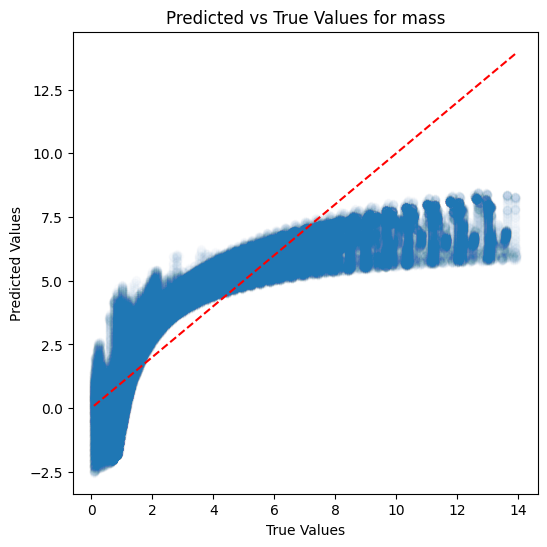

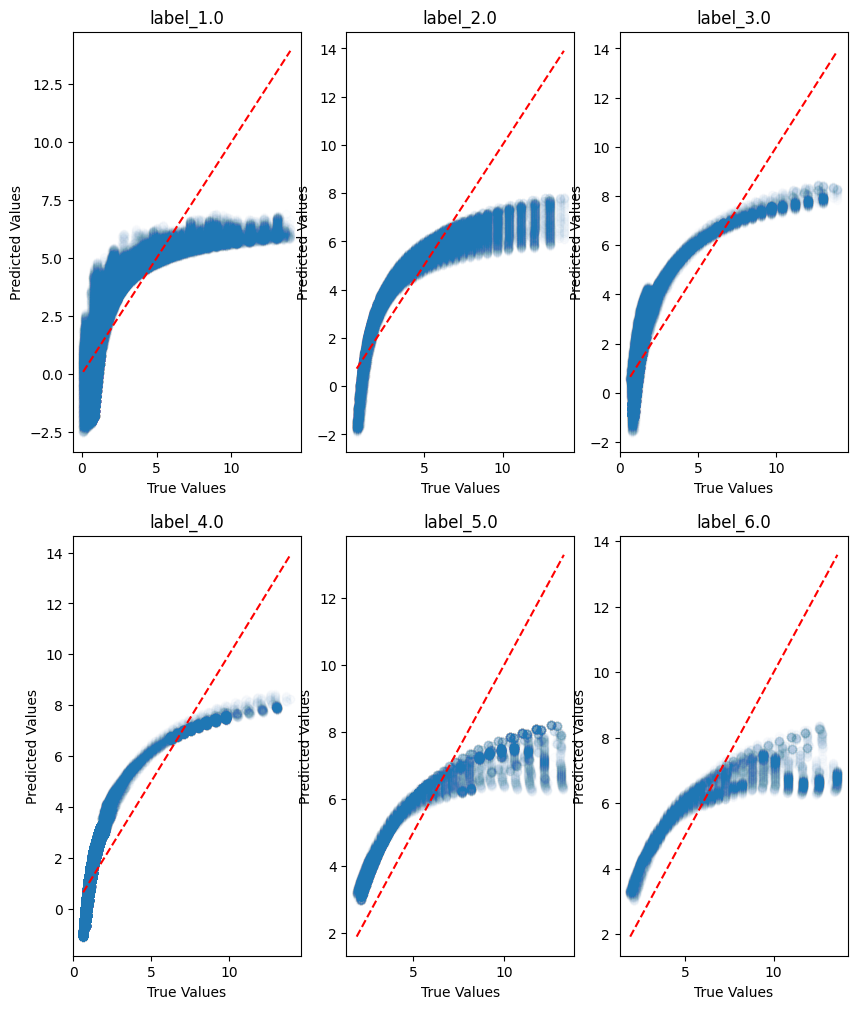

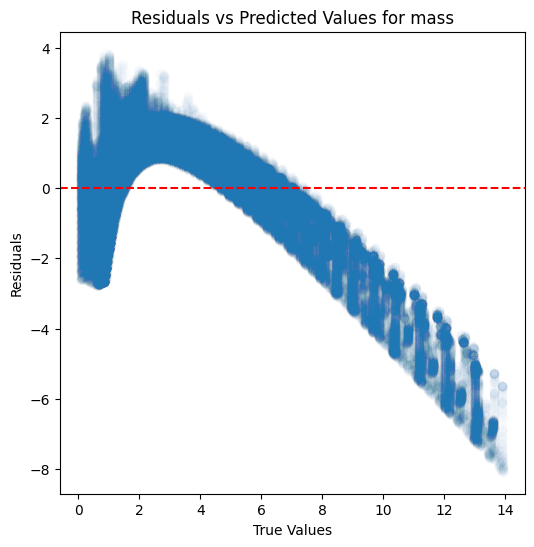

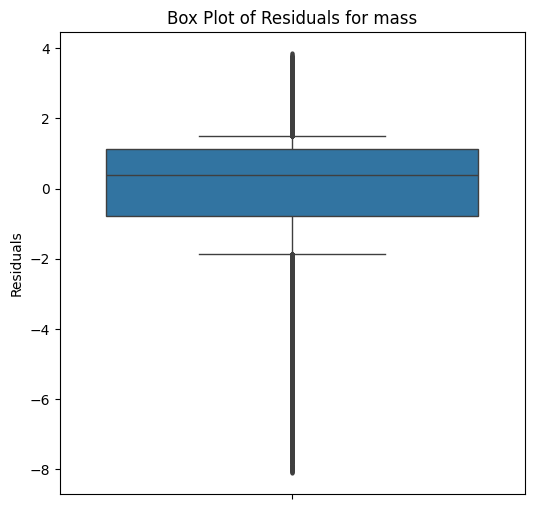

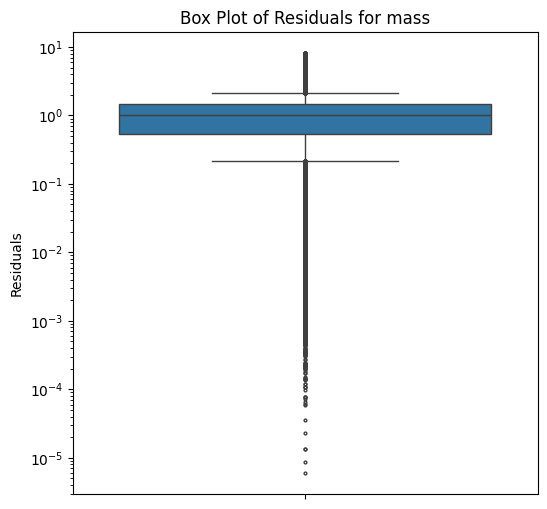

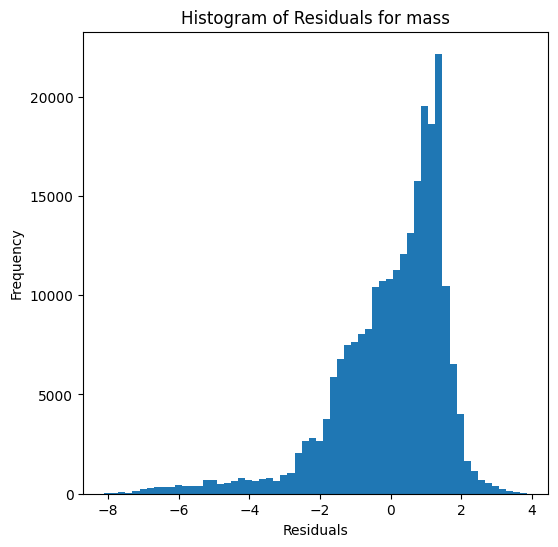

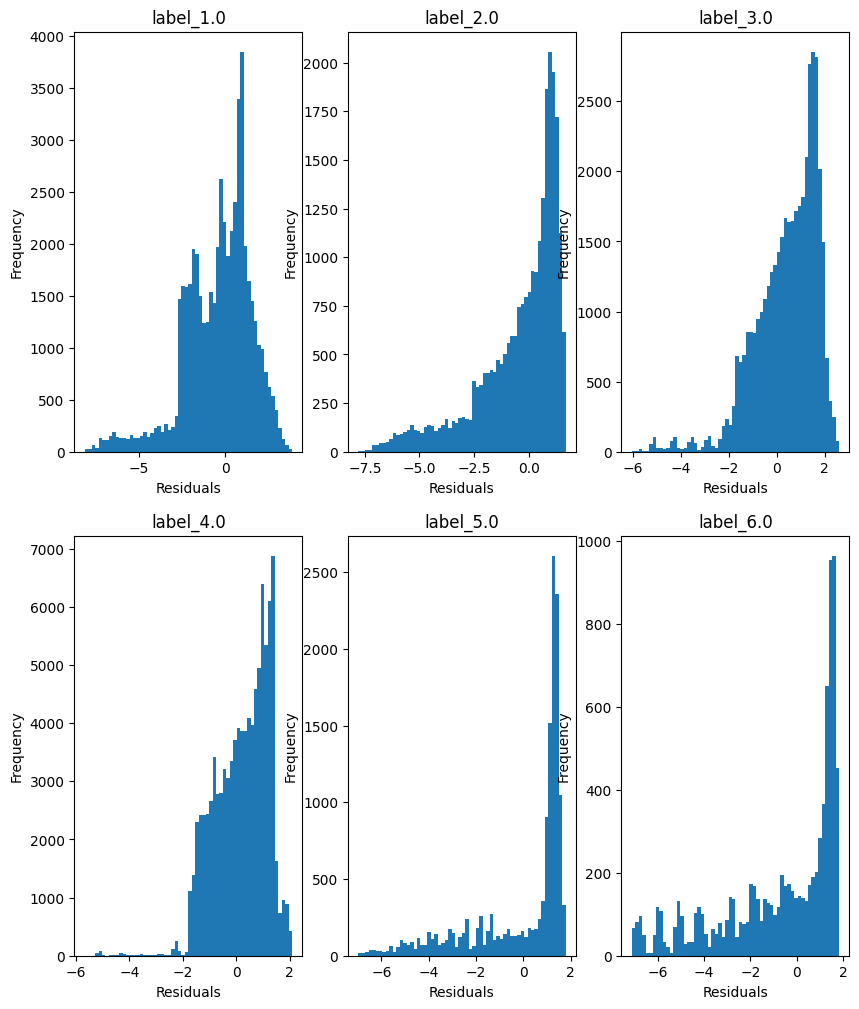

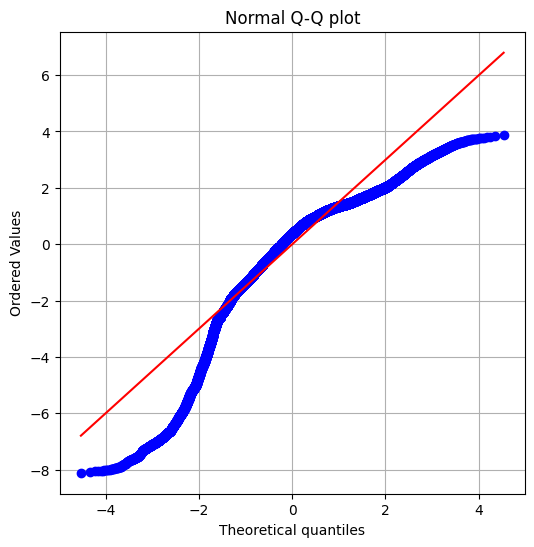

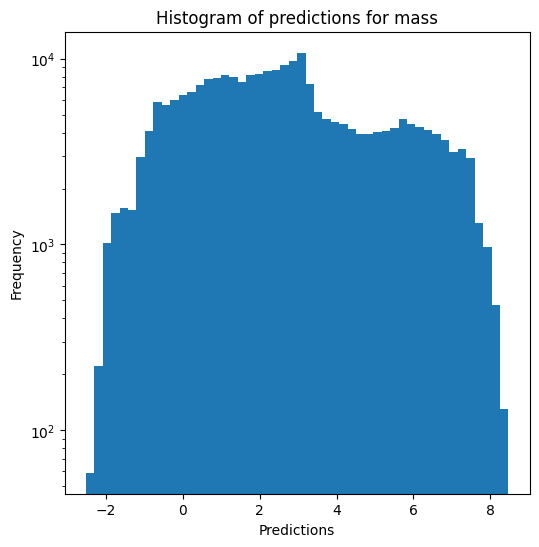

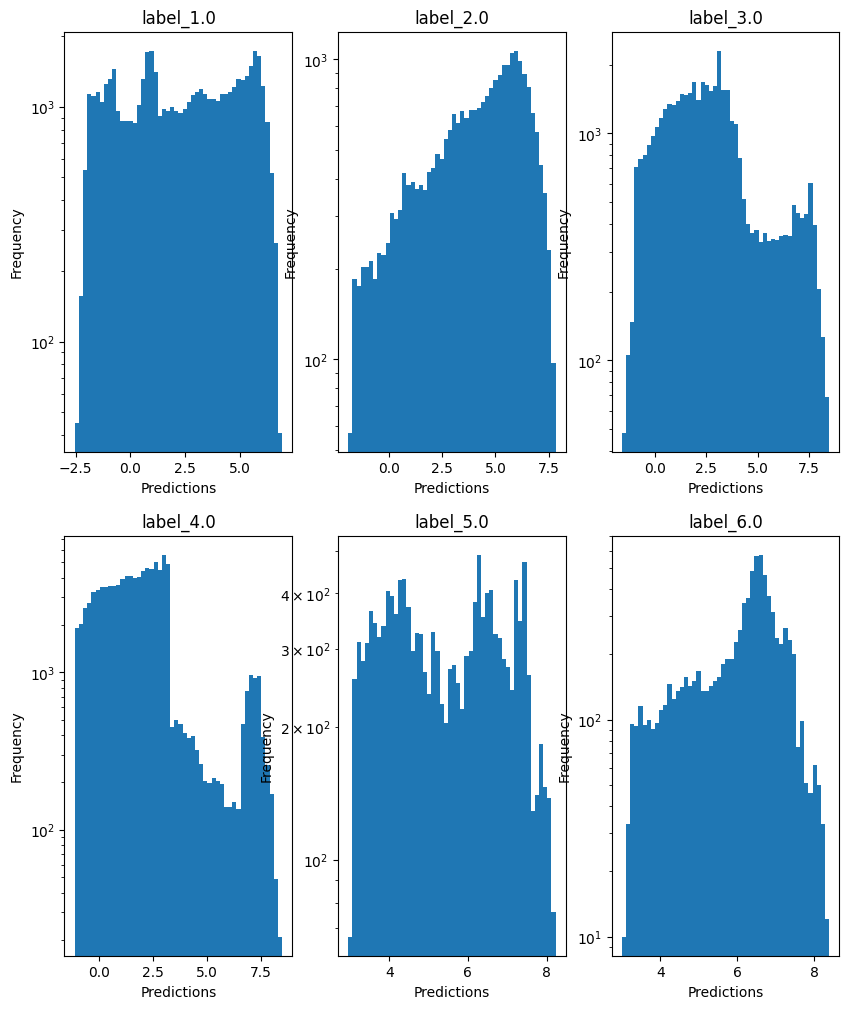

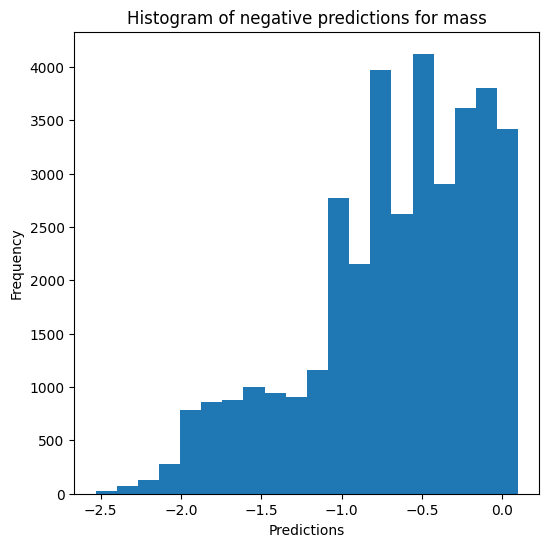


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.8633268631959411
  RMSE :  0.13636580742533463
  MAE :  0.0947997753751004
  MedAE :  0.07114669719234962
  CORR :  0.947904503108817
  MAX_ER :  0.6003968952865596
  Percentiles : 
    75th percentile :  0.11952949597255852
    90th percentile :  0.19704696251800163
    95th percentile :  0.30226138785216145
    99th percentile :  0.5001035654360226

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9926715890480522
  RMSE :  0.06484238666534067
  MAE :  0.04630289686925582
  MedAE :  0.029399054856810547
  CORR :  0.9963312775041202
  MAX_ER :  0.22343624995530842
  Percentiles : 
    75th percentile :  0.07041539686939816
    90th percentile :  0.11419363762037384
    95th percentile :  0.14127464668413953
    99th percentile :  0.1874372014434546

radius results for the label catego

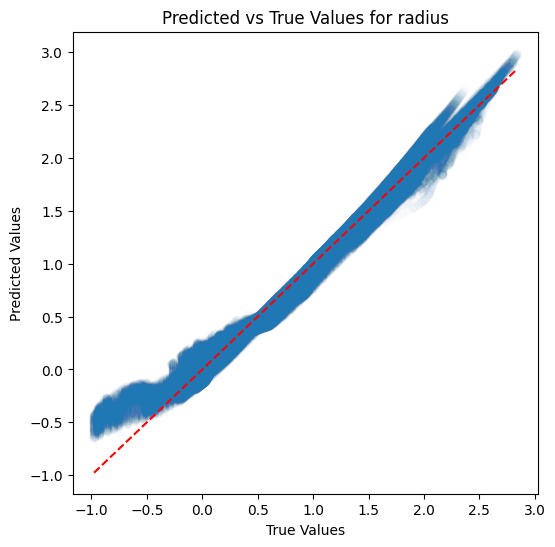

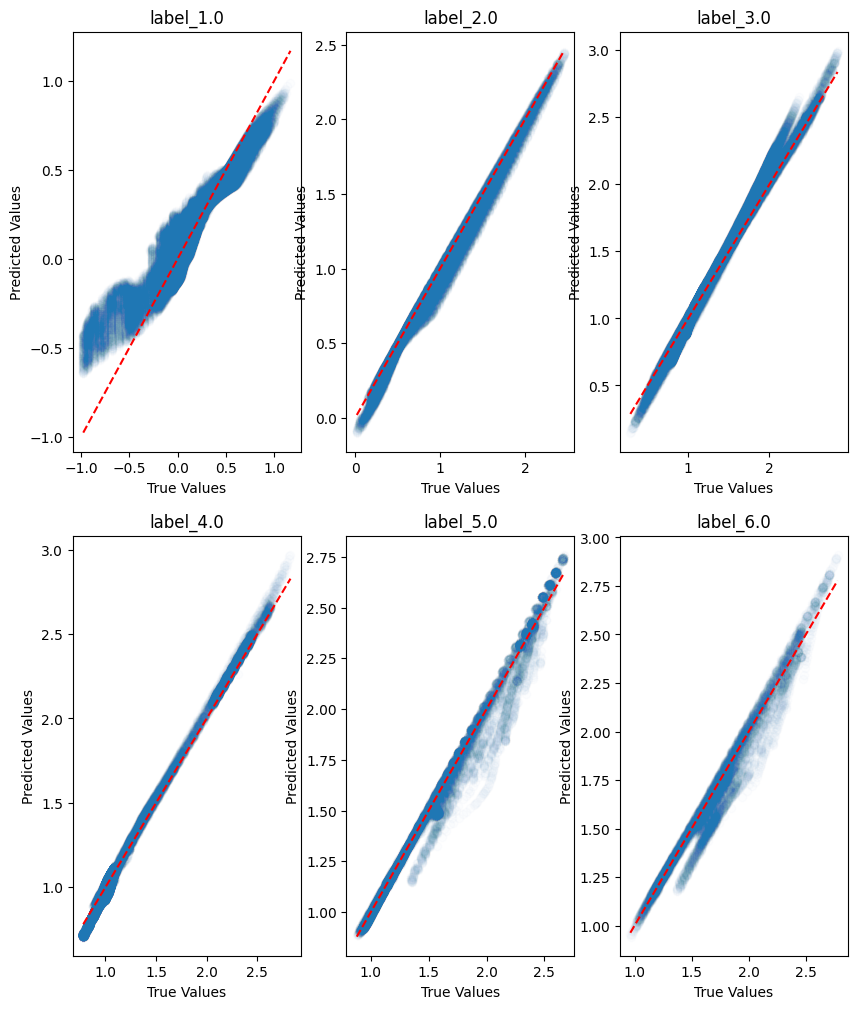

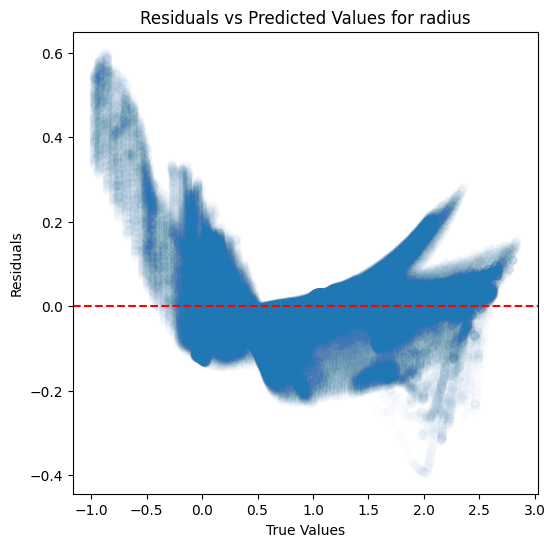

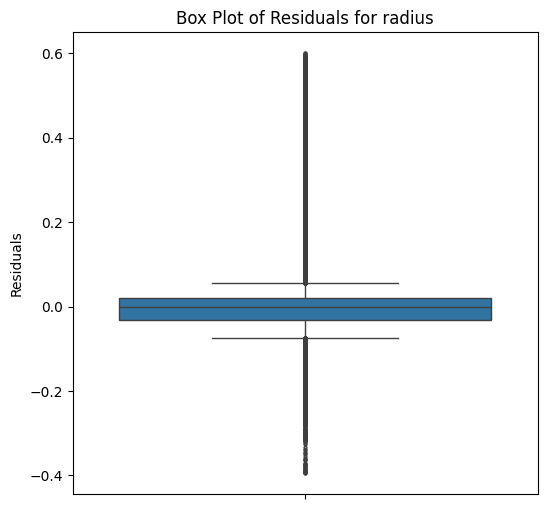

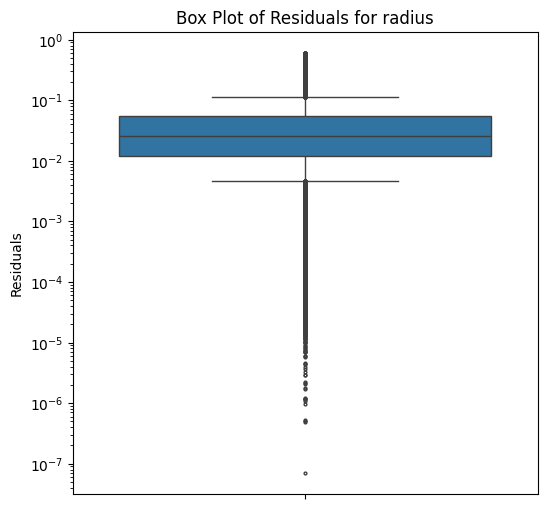

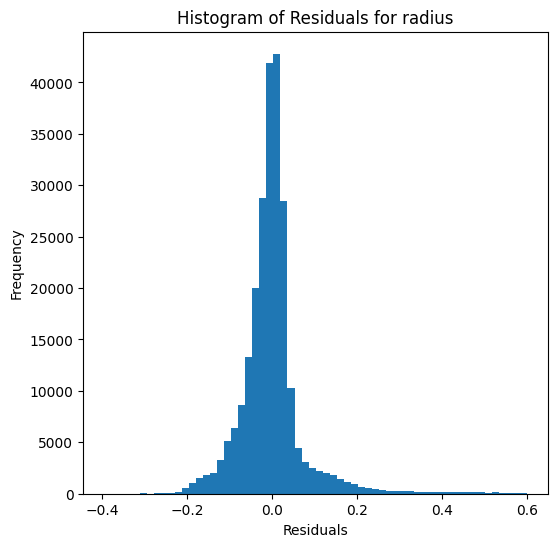

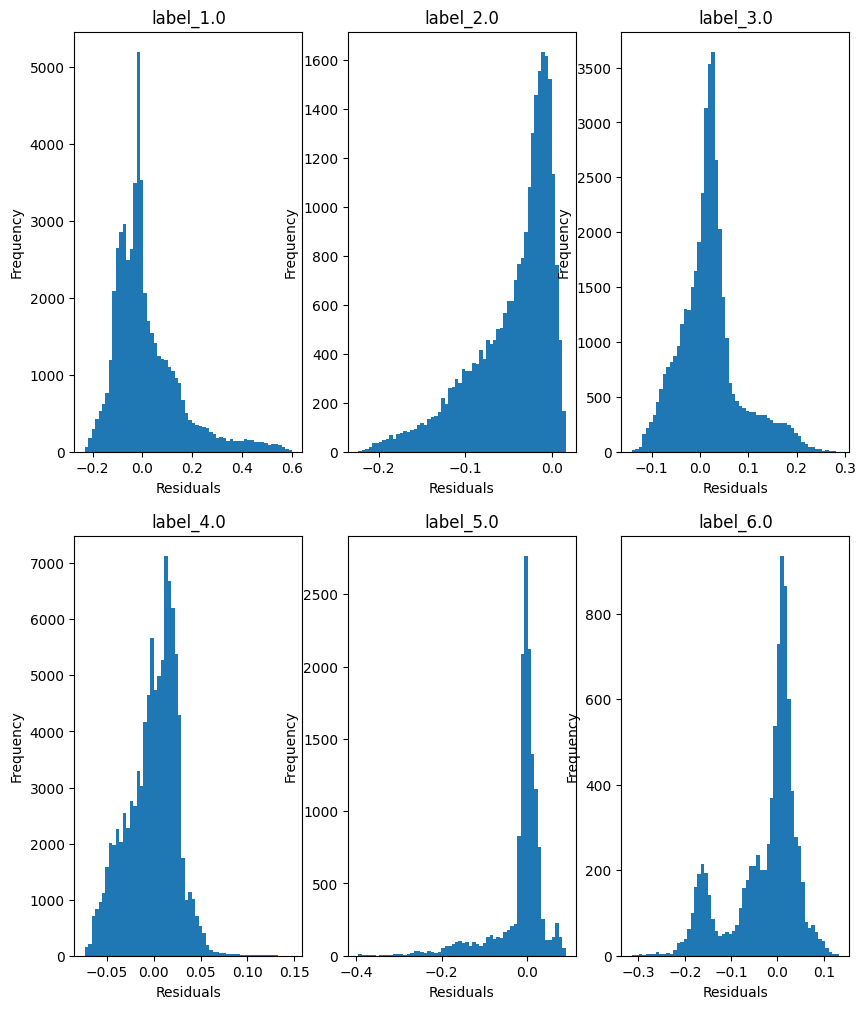

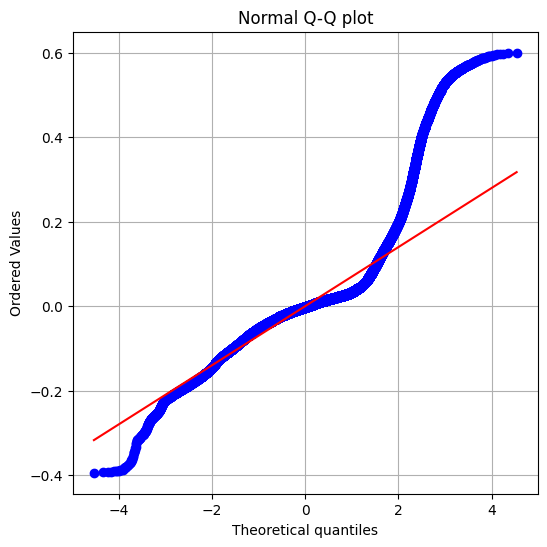

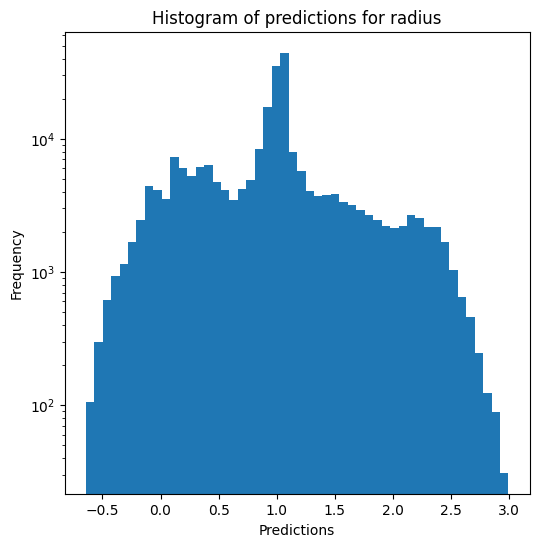

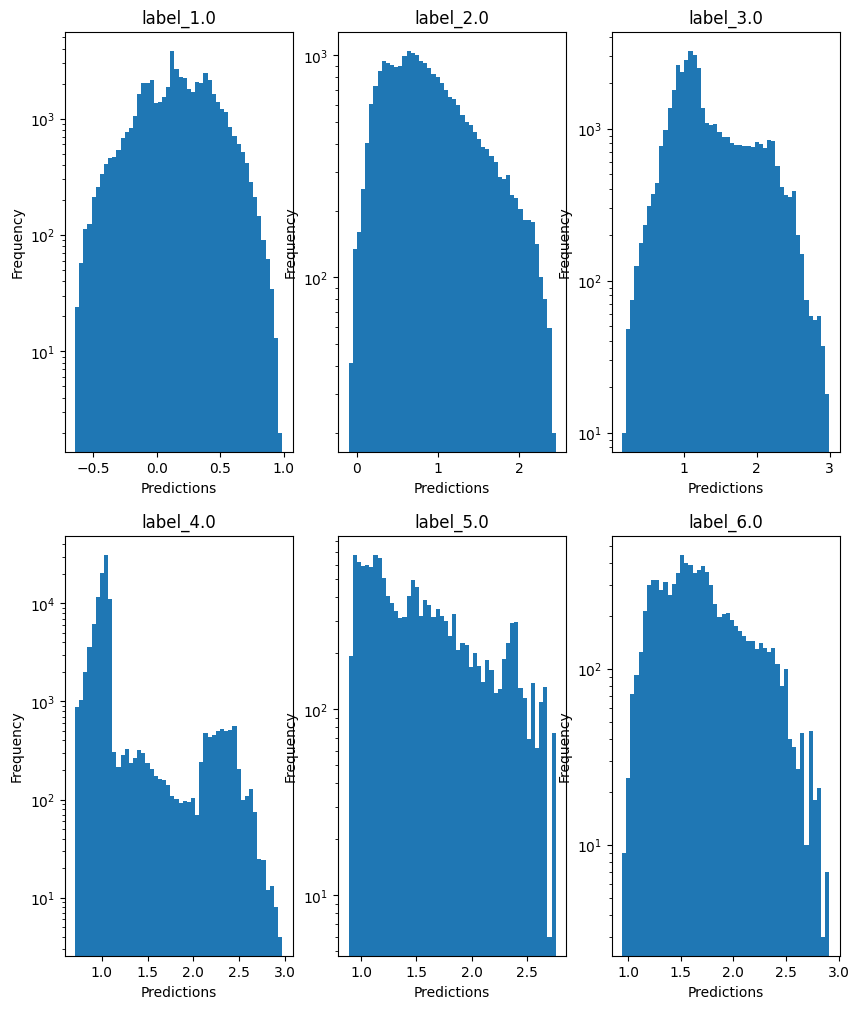

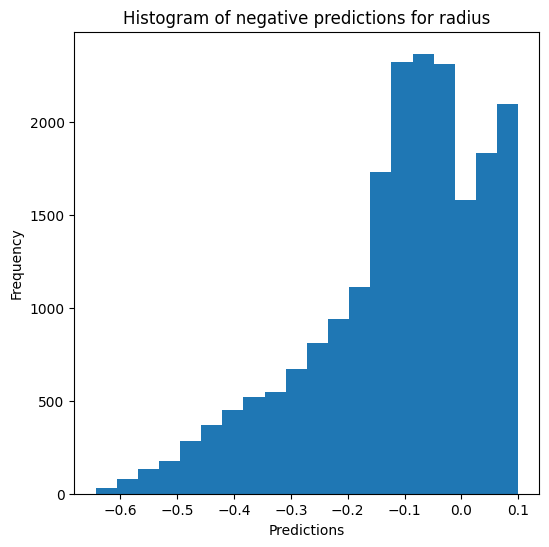

Saving predictions and results...


In [11]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name) #, override=False, use_preds=True

### Decision tree

In [12]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9996230558807472
  RMSE :  0.05858669024842603
  MAE :  0.013496367971439074
  MedAE :  0.0
  CORR :  0.9998115509519013
  MAX_ER :  1.343
  Percentiles : 
    75th percentile :  0.0010000000000000009
    90th percentile :  0.02100000000000013
    95th percentile :  0.06899999999999995
    99th percentile :  0.2919999999999998

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9999465290840783
  RMSE :  0.024519725301464297
  MAE :  0.006331873837569775
  MedAE :  0.0
  CORR :  0.9999733680596143
  MAX_ER :  0.5760000000000005
  Percentiles : 
    75th percentile :  0.0009999999999994458
    90th percentile :  0.016999999999999904
    95th percentile :  0.041999999999999815
    99th percentile :  0.10099999999999998

mass results for the label category with a value of 3.0
  value range :  0.655 - 13.903
  RVE :  0.9999173845360345
  RMSE : 

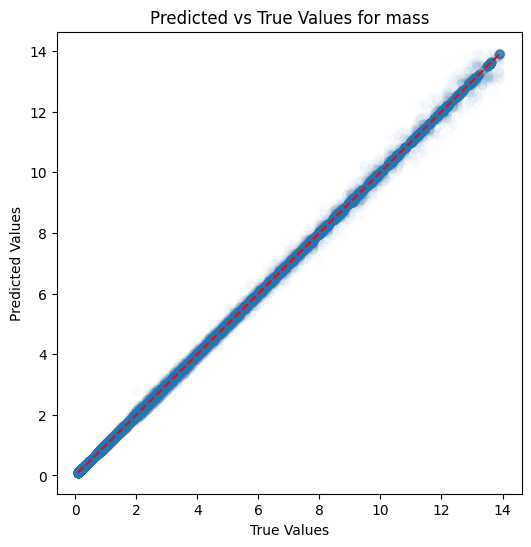

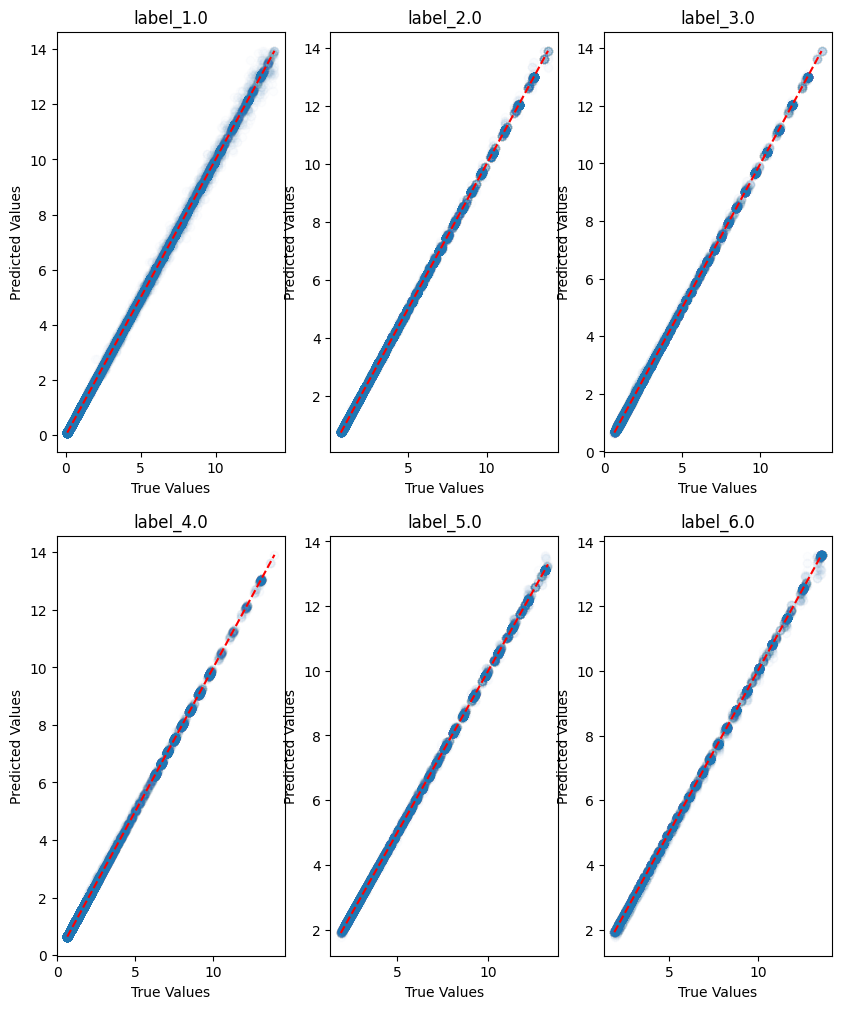

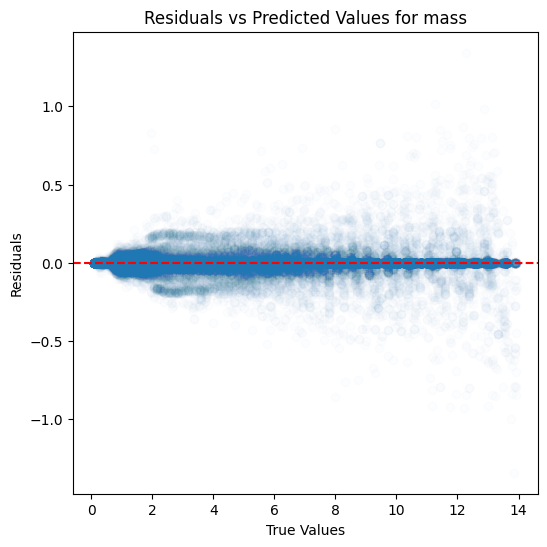

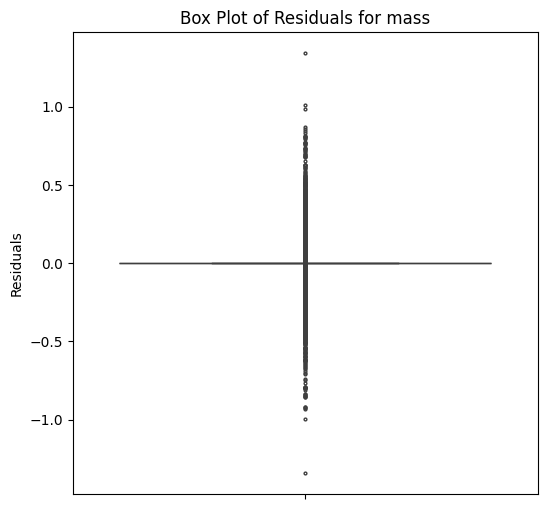

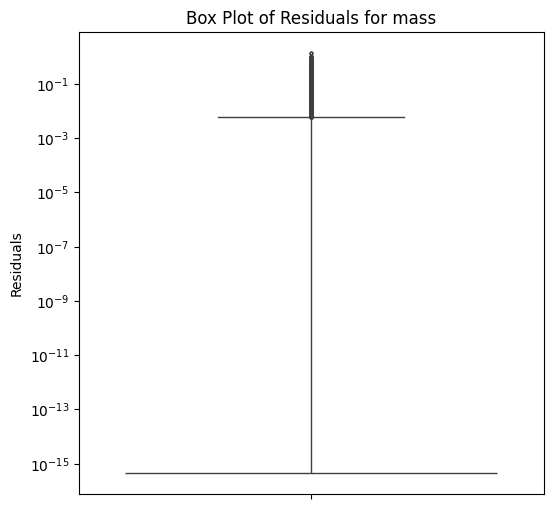

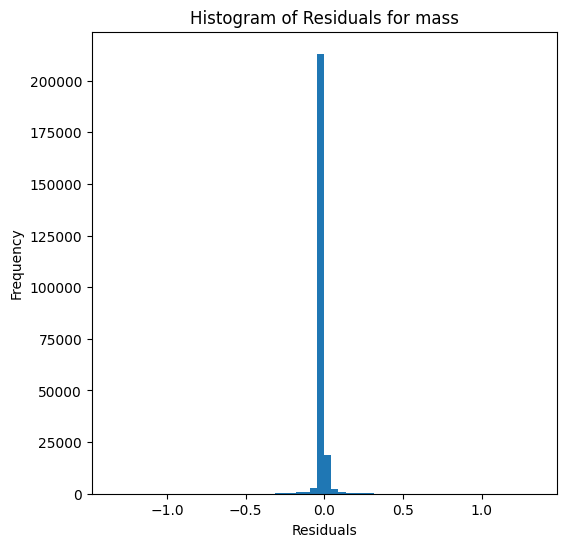

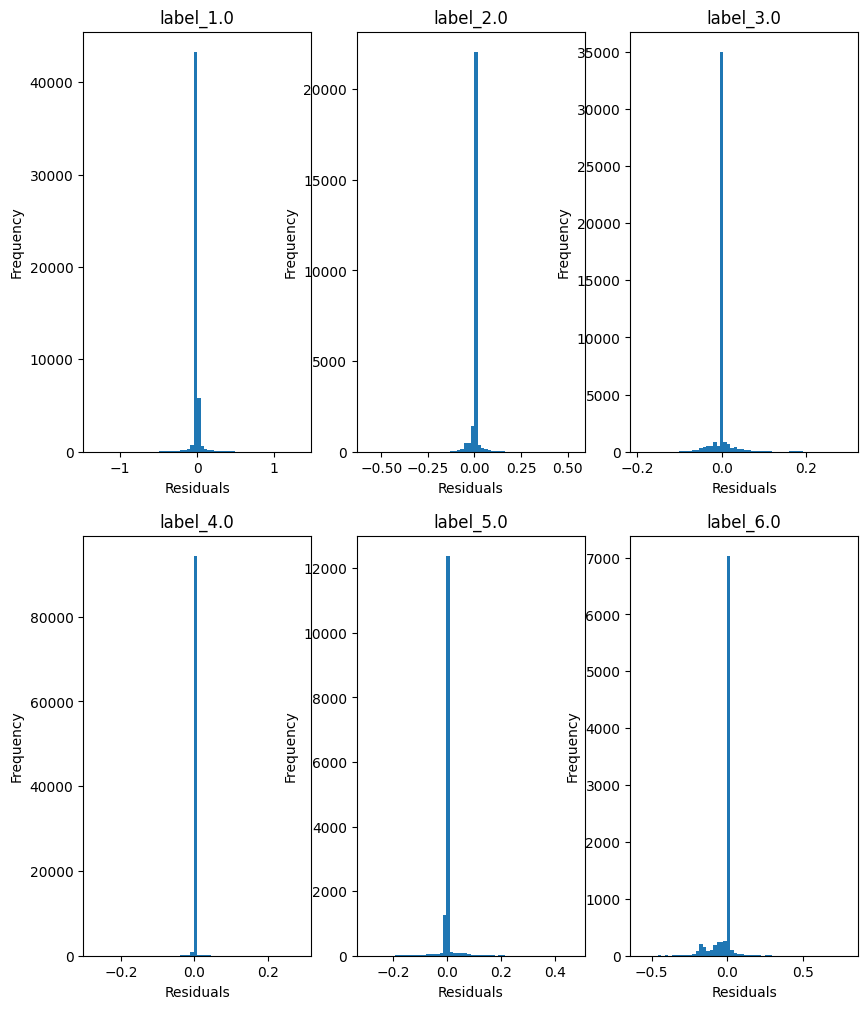

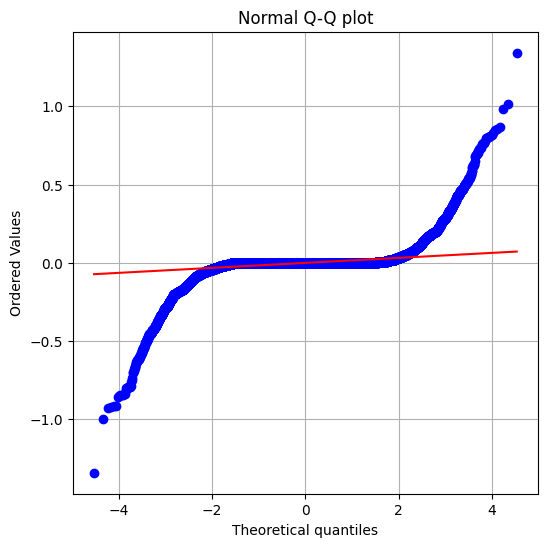

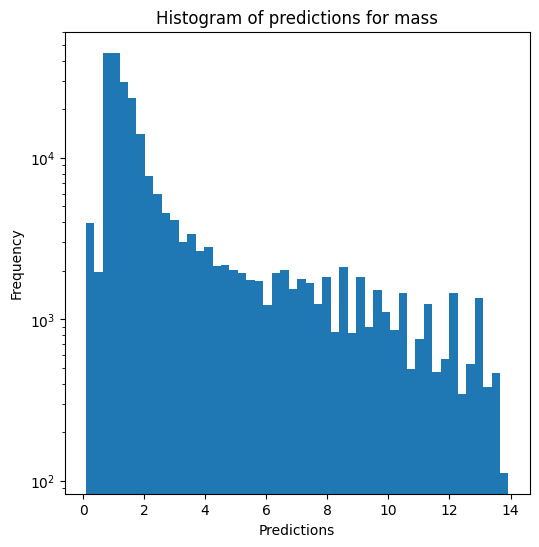

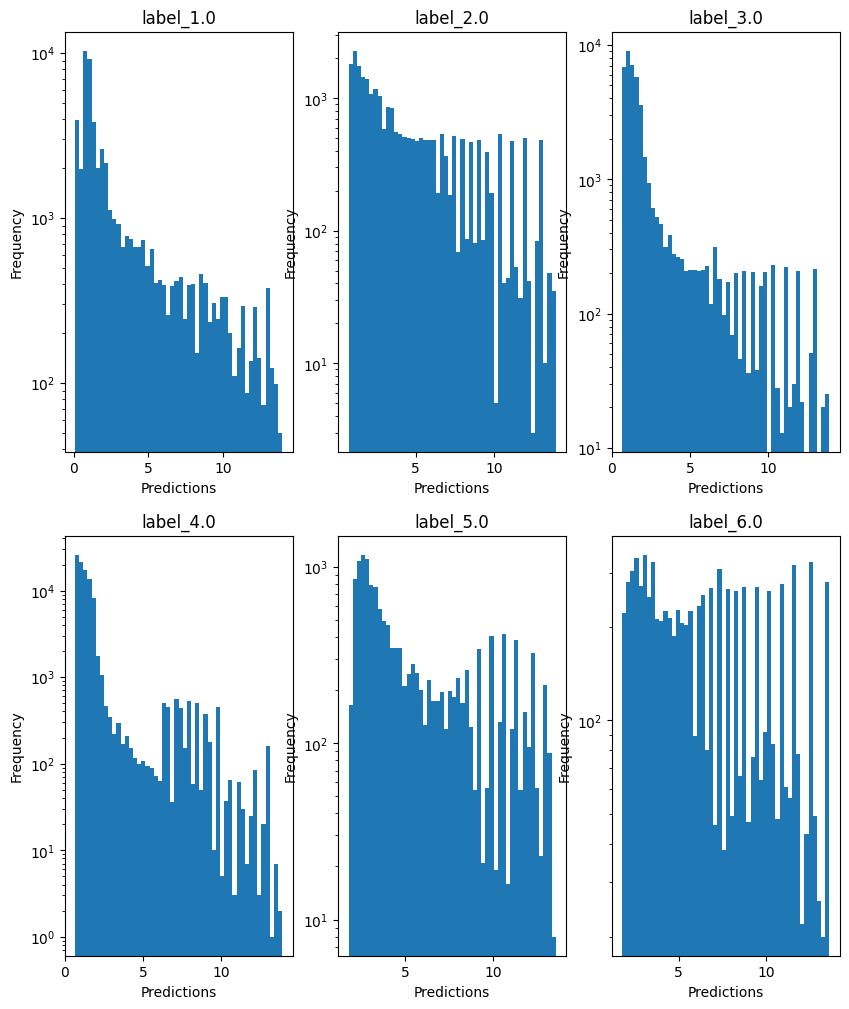

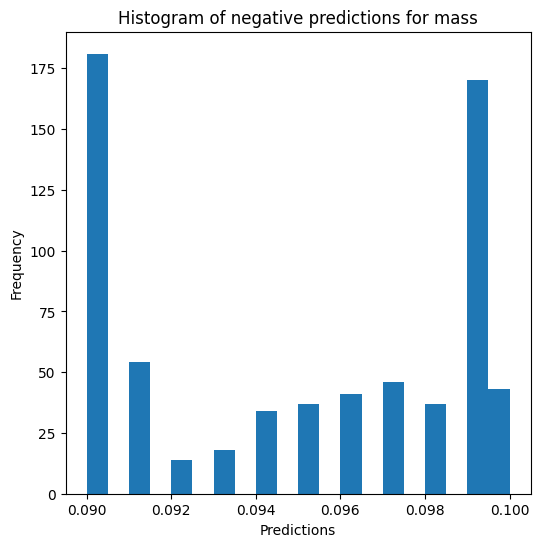

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9996564007513136
  RMSE :  0.006785021901969423
  MAE :  0.00249207183824716
  MedAE :  2.7755575615628914e-17
  CORR :  0.9998282232185345
  MAX_ER :  0.15067566342895866
  Percentiles : 
    75th percentile :  0.0017315194996180491
    90th percentile :  0.007572701756034167
    95th percentile :  0.013403118027987227
    99th percentile :  0.03152139461086285

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9993048071005244
  RMSE :  0.014266158308167798
  MAE :  0.005555902383746479
  MedAE :  0.0
  CORR :  0.9996560028468366
  MAX_ER :  0.3373776625458338
  Percentiles : 
    75th percentile :  0.006675492750017775
    90th percentile :  0.019548508403933407
    95th percentile :  0.02568838827624764
    99th percentile :  0.04766551264447627

radius results for the label categor

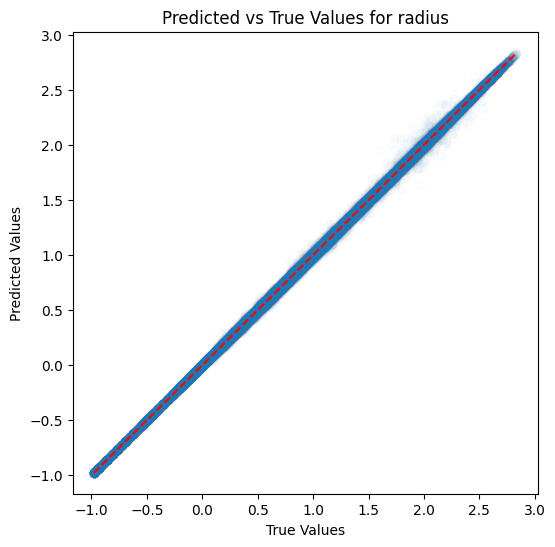

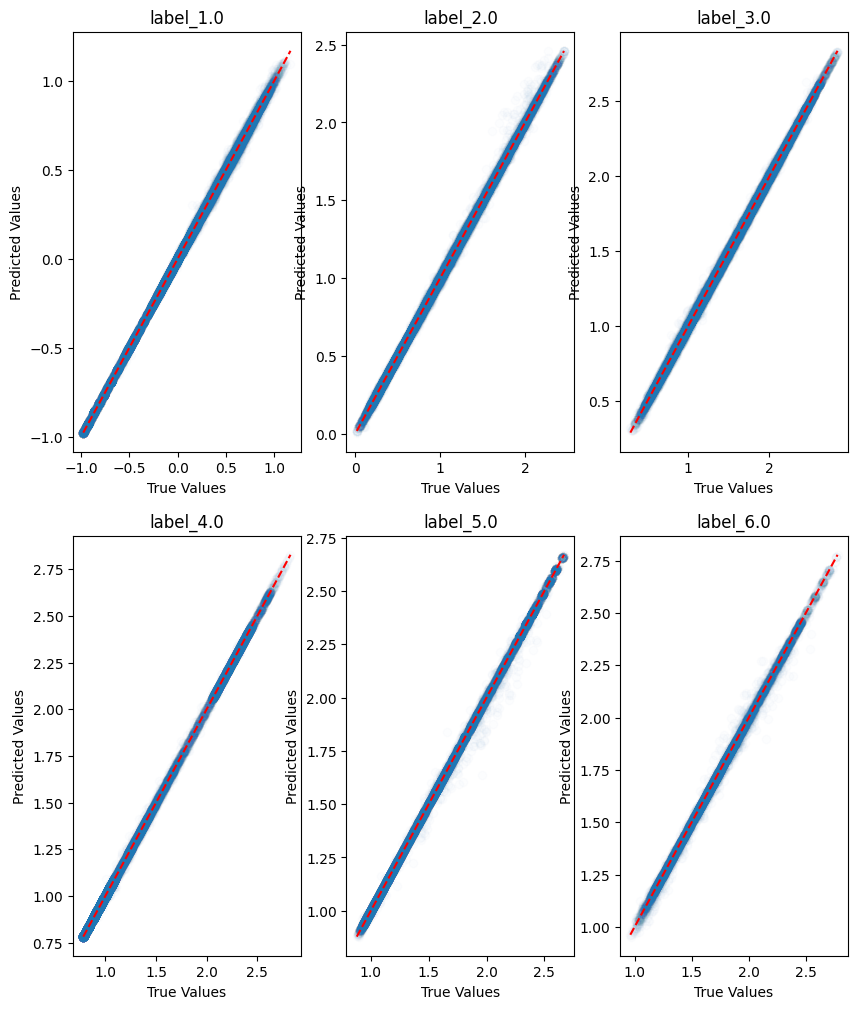

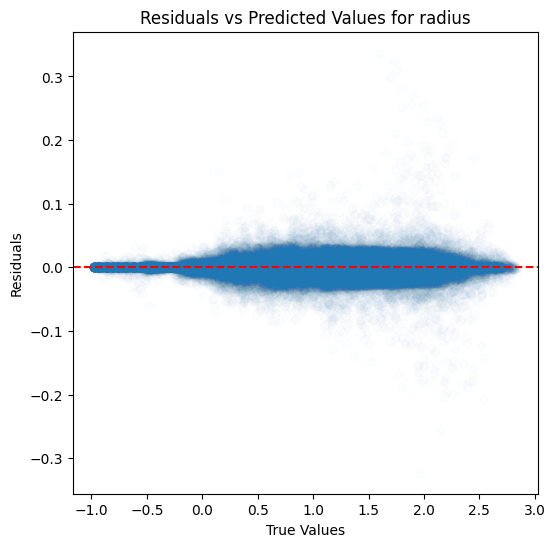

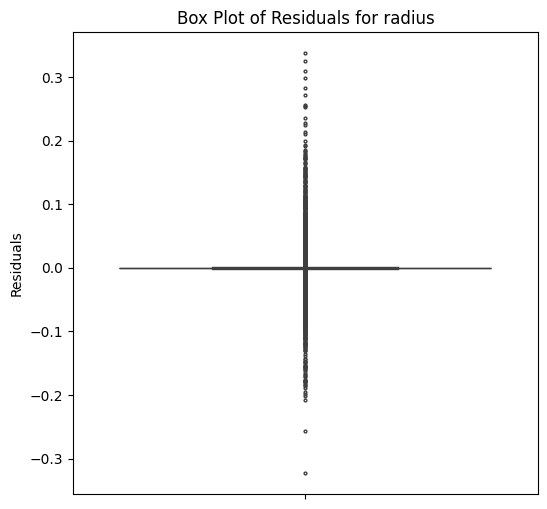

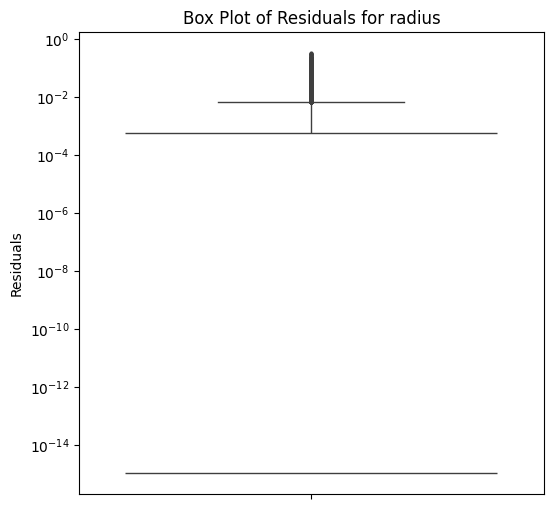

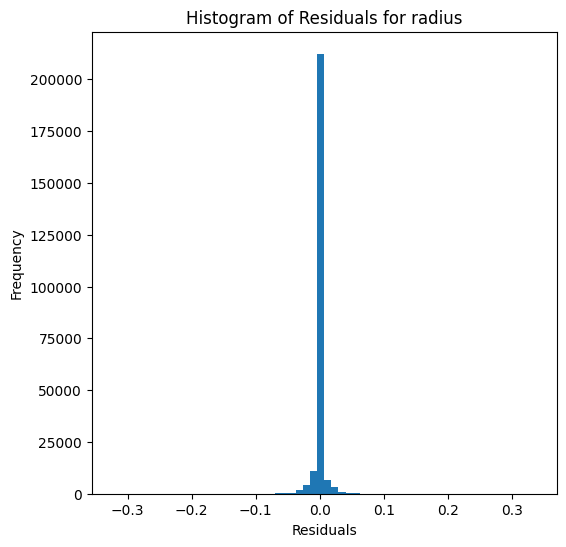

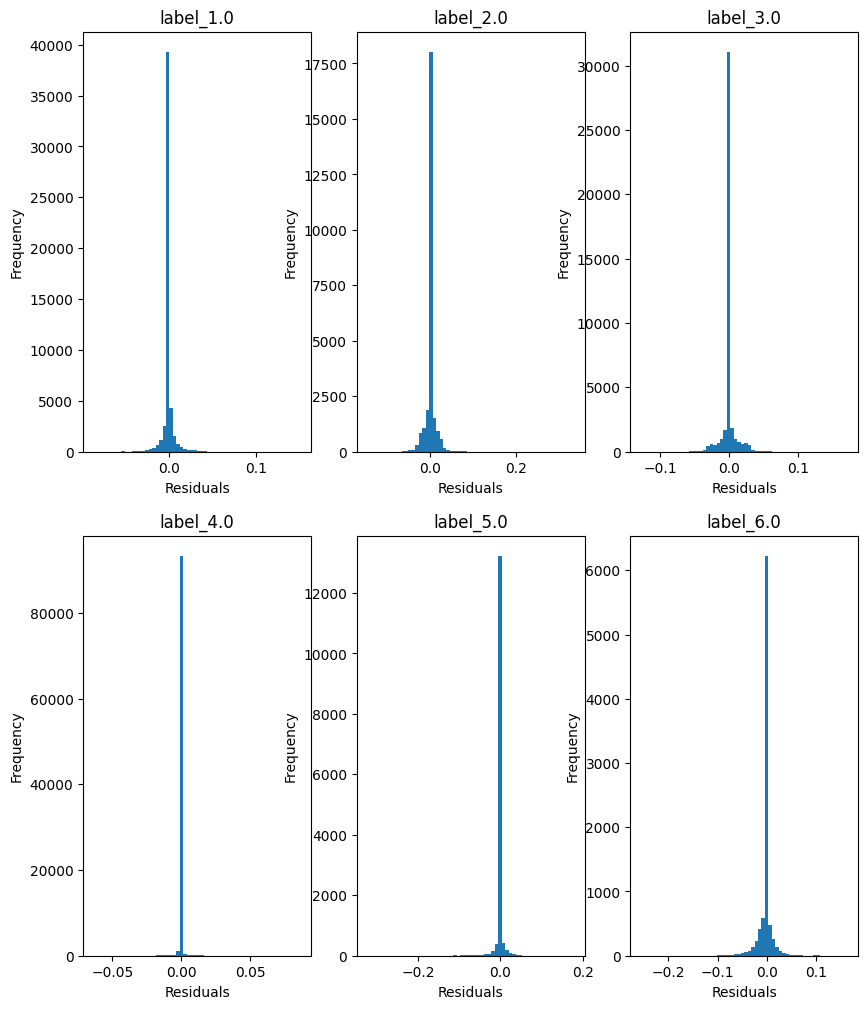

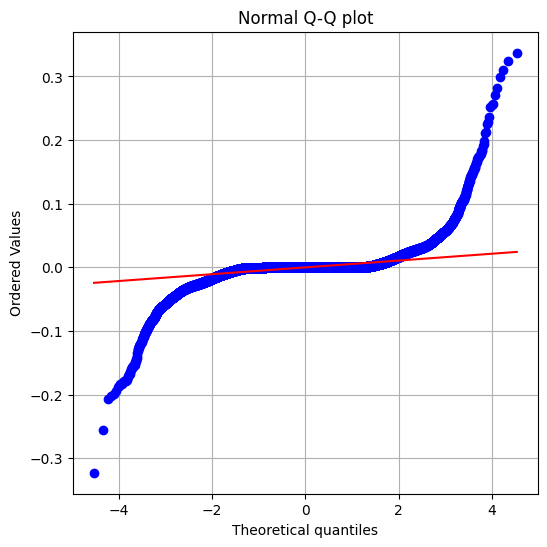

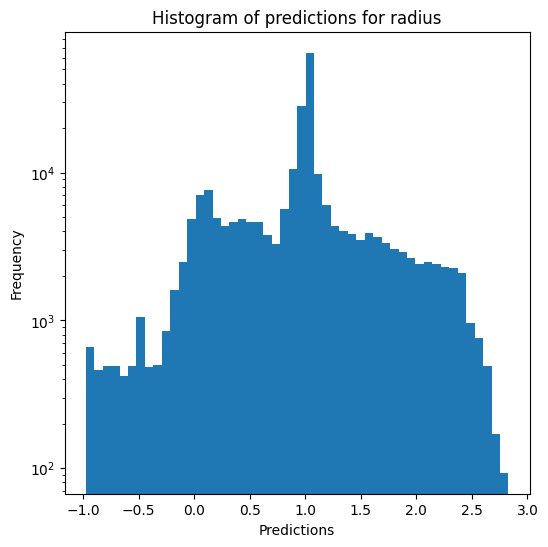

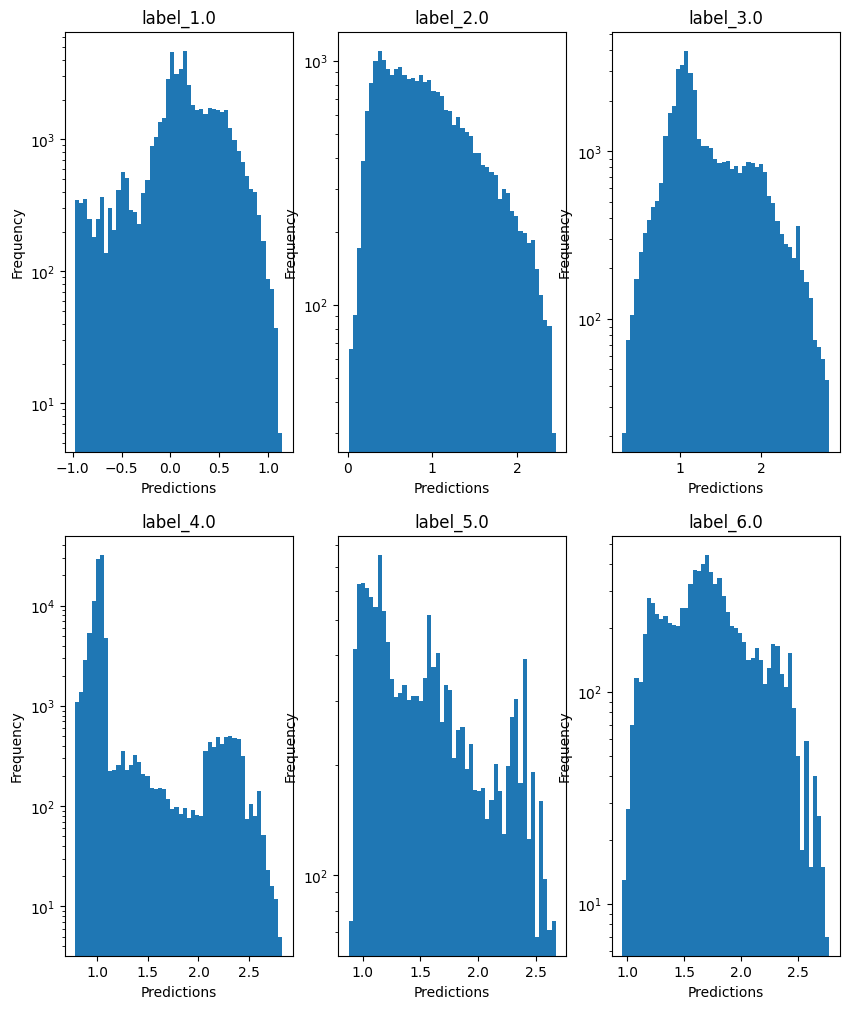

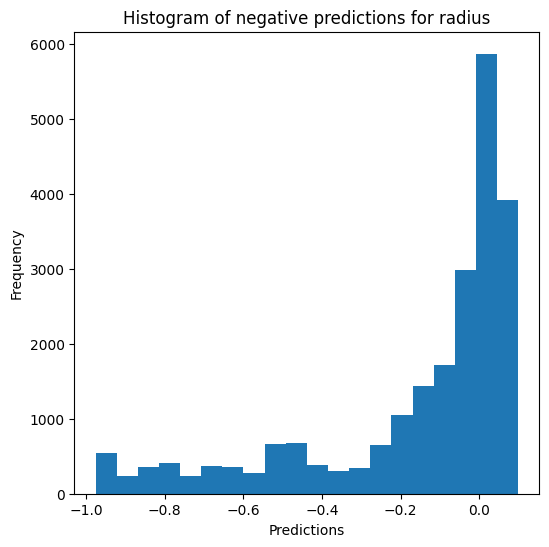

Saving predictions and results...


In [13]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### K-nearest neighbours

In [14]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9965086325857763
  RMSE :  0.17830533936952708
  MAE :  0.07693397263389302
  MedAE :  0.016600000000000004
  CORR :  0.9982626403190129
  MAX_ER :  3.3583999999999996
  Percentiles : 
    75th percentile :  0.0706
    90th percentile :  0.21890000000000054
    95th percentile :  0.3685999999999996
    99th percentile :  0.8268000000000004

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9965995955985715
  RMSE :  0.19644558989899102
  MAE :  0.08831885461872288
  MedAE :  0.022399999999999753
  CORR :  0.998303232425027
  MAX_ER :  1.9445999999999994
  Percentiles : 
    75th percentile :  0.08640000000000025
    90th percentile :  0.2510600000000004
    95th percentile :  0.4050000000000005
    99th percentile :  0.926585999999999

mass results for the label category with a value of 3.0
  value range :  0.655 - 13.903
  RVE :  0.9987999

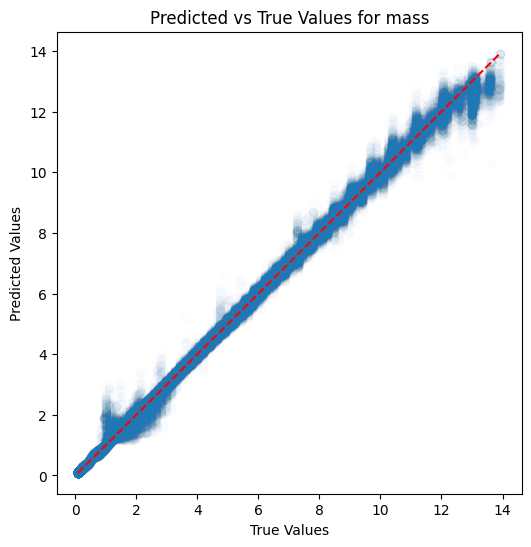

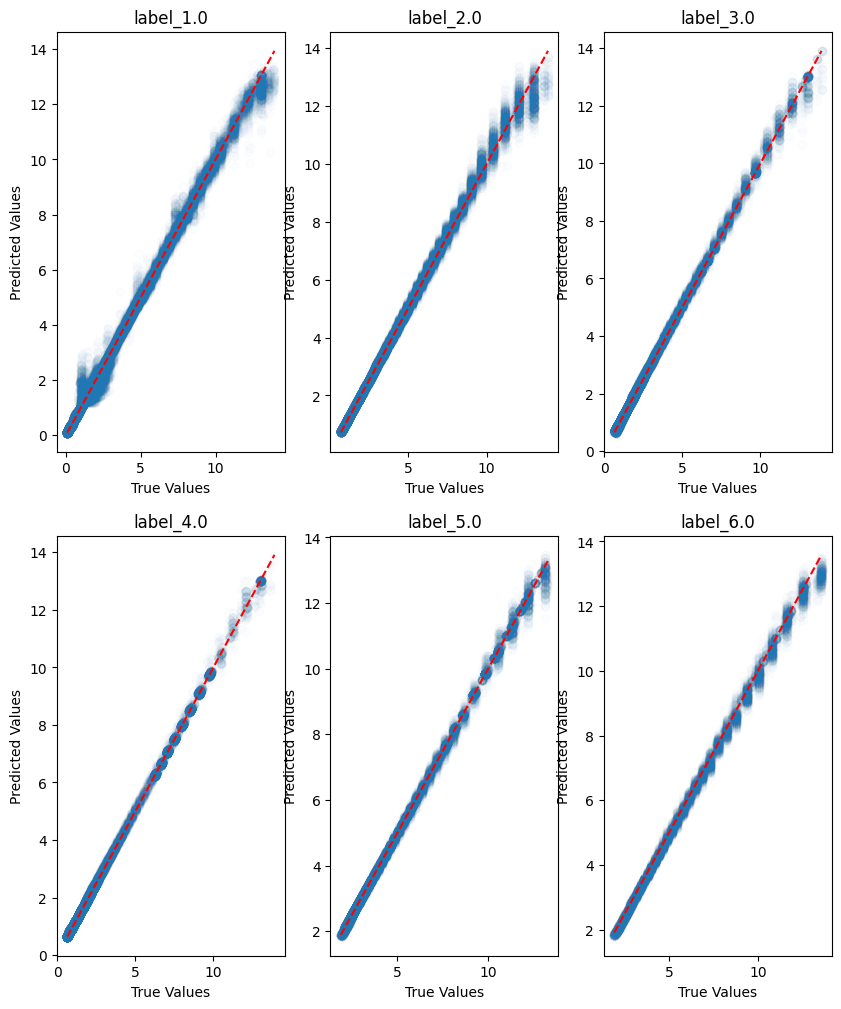

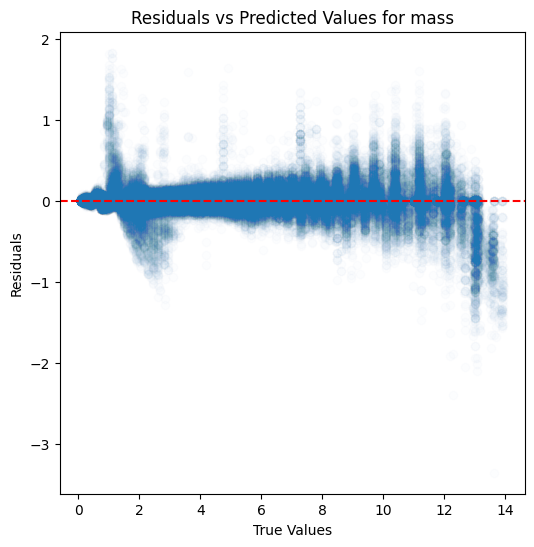

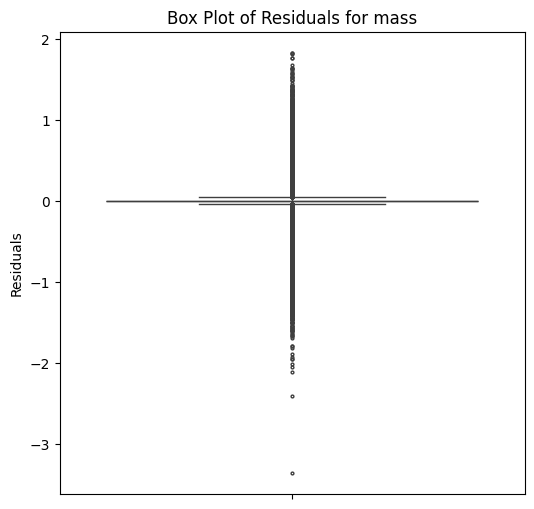

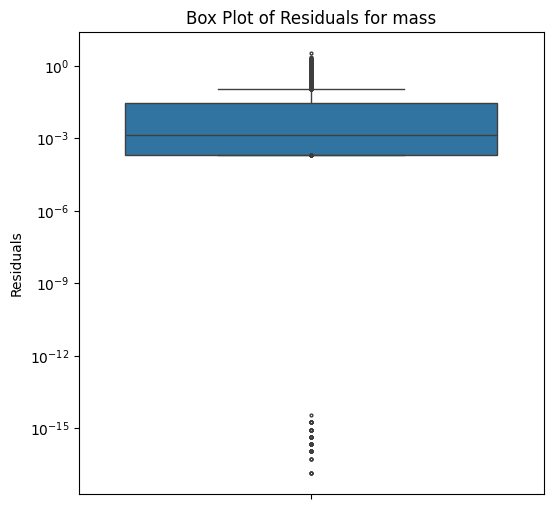

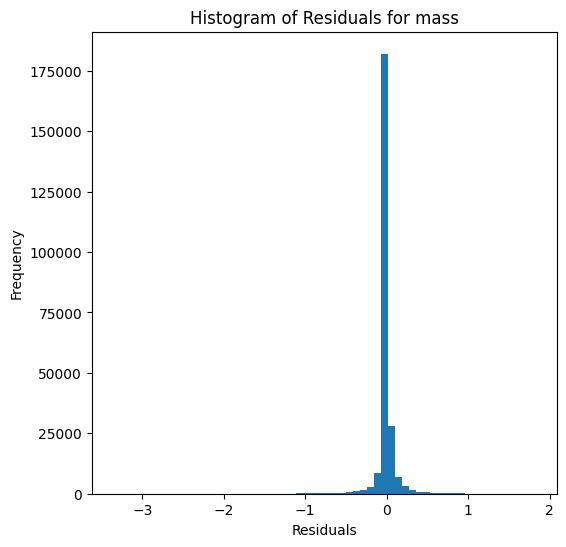

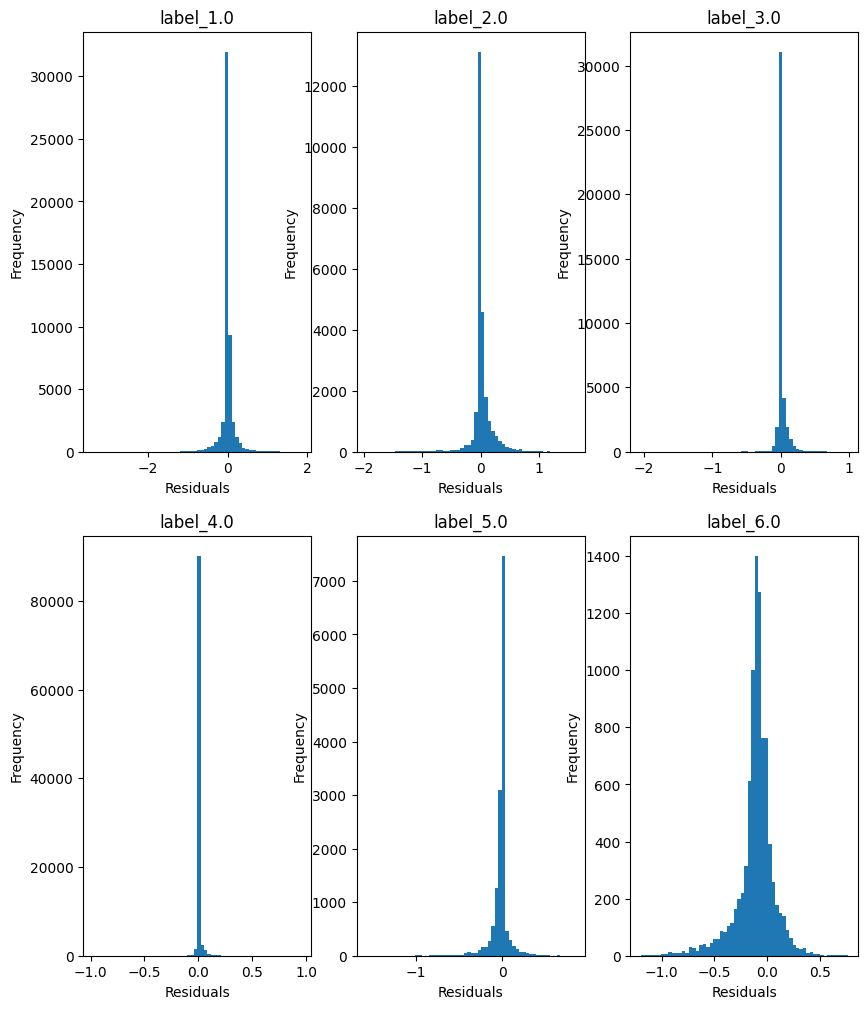

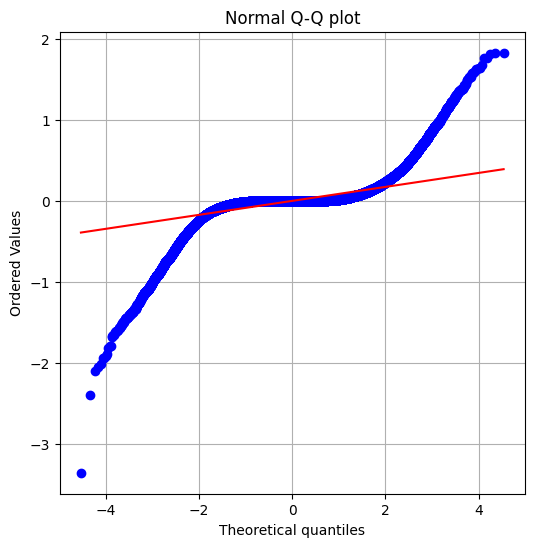

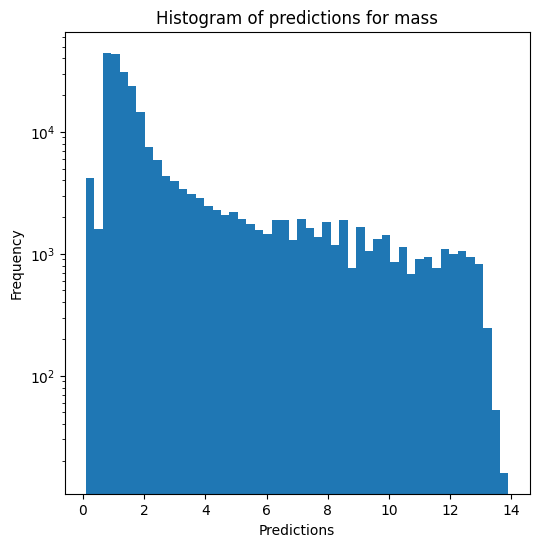

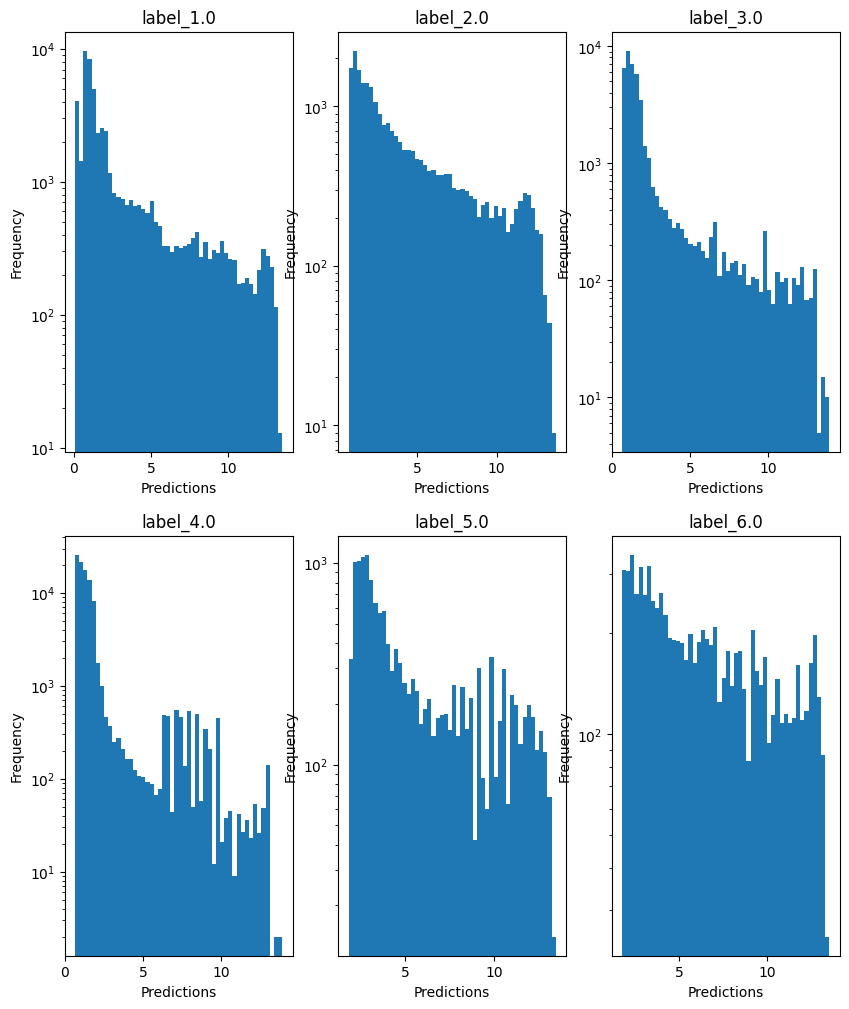

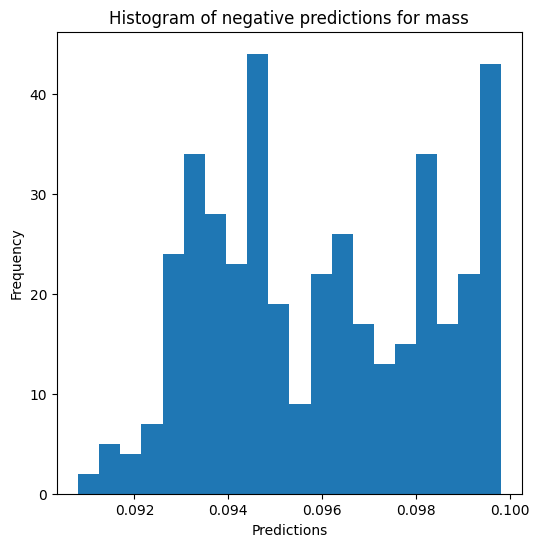


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9968461422994368
  RMSE :  0.020565776651618742
  MAE :  0.01082095587001623
  MedAE :  0.0050221164060123
  CORR :  0.9984264773639977
  MAX_ER :  0.22422949341588558
  Percentiles : 
    75th percentile :  0.012686600663698033
    90th percentile :  0.02749132371740029
    95th percentile :  0.04268915201015239
    99th percentile :  0.08775857944313775

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9991082824515929
  RMSE :  0.016425286483859363
  MAE :  0.008445497285962226
  MedAE :  0.0051462812666067115
  CORR :  0.99962521031915
  MAX_ER :  0.26904297331078575
  Percentiles : 
    75th percentile :  0.009573157964402543
    90th percentile :  0.01608049107624197
    95th percentile :  0.02373145085029122
    99th percentile :  0.07113155339415937

radius results for the labe

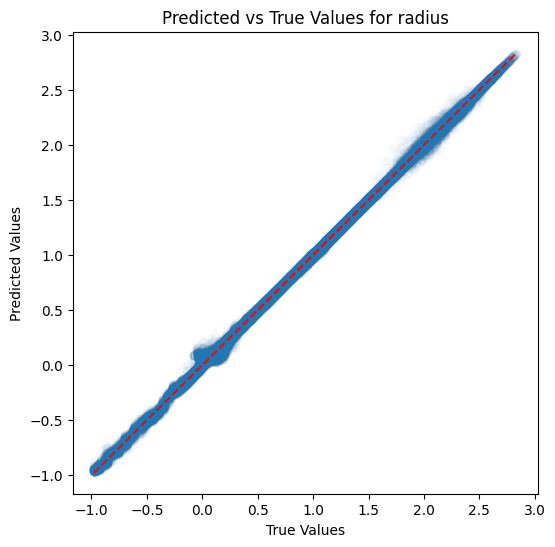

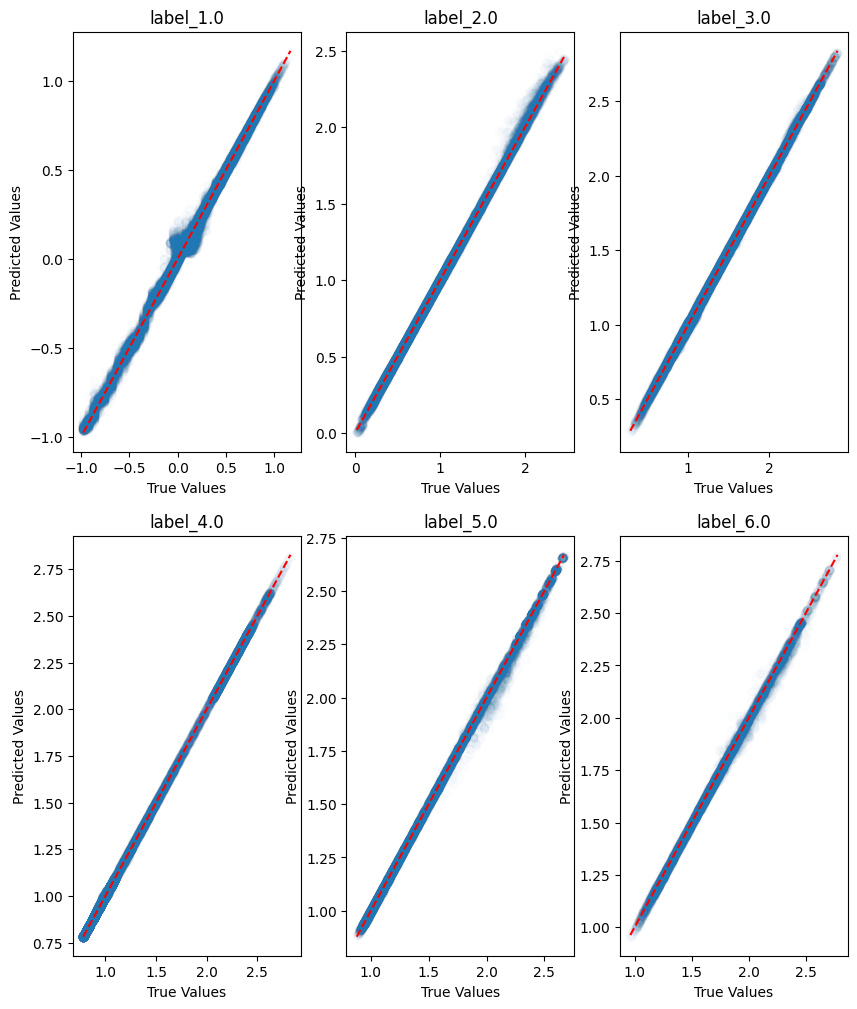

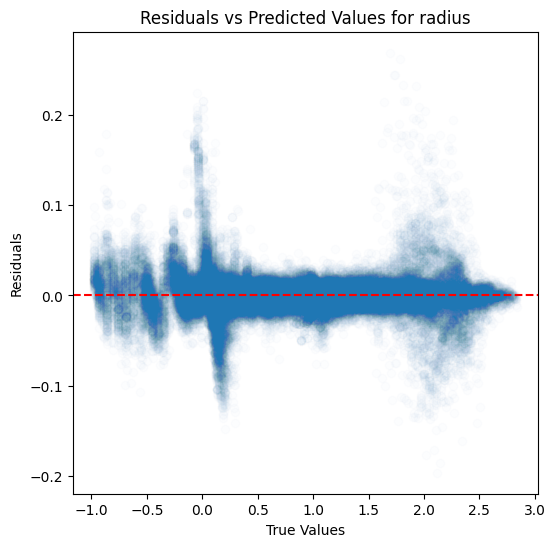

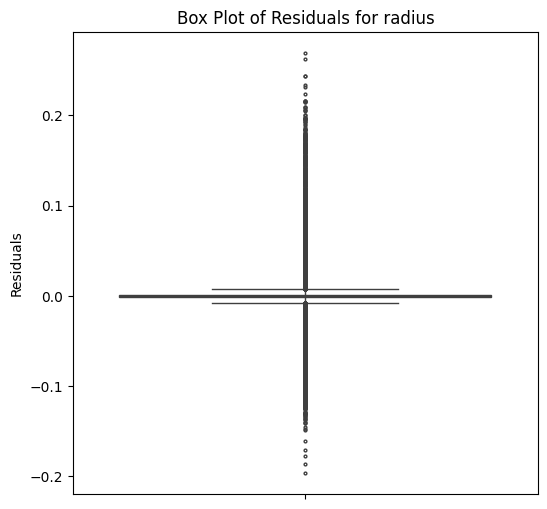

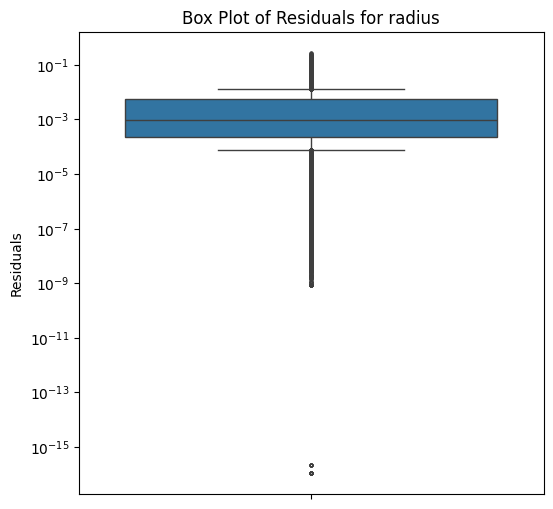

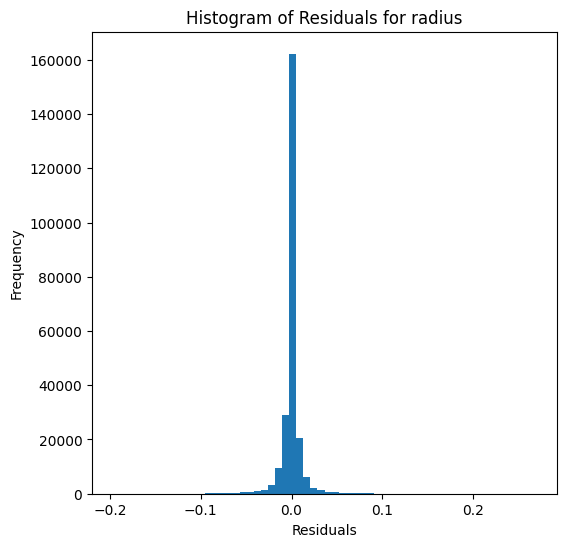

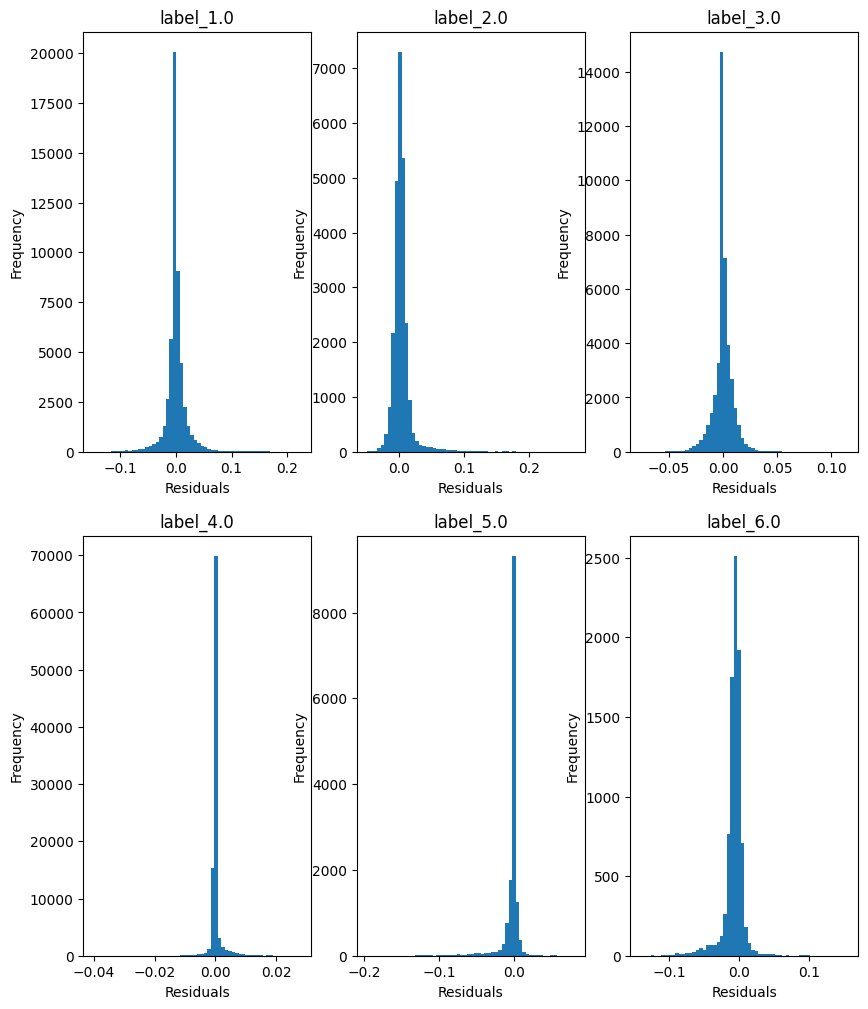

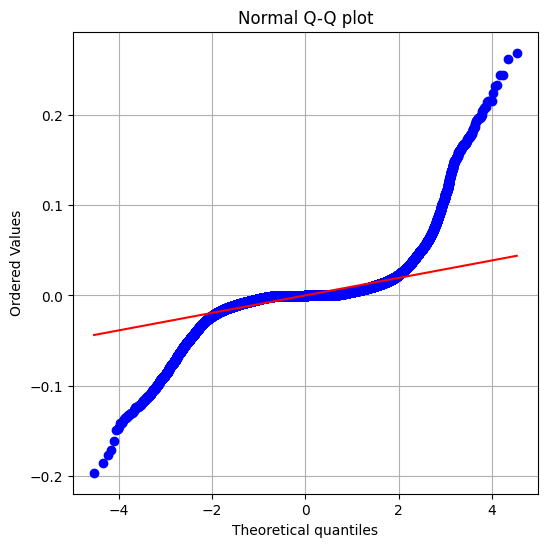

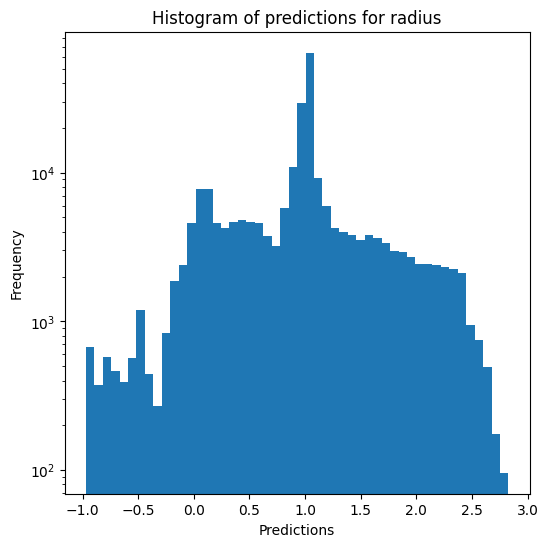

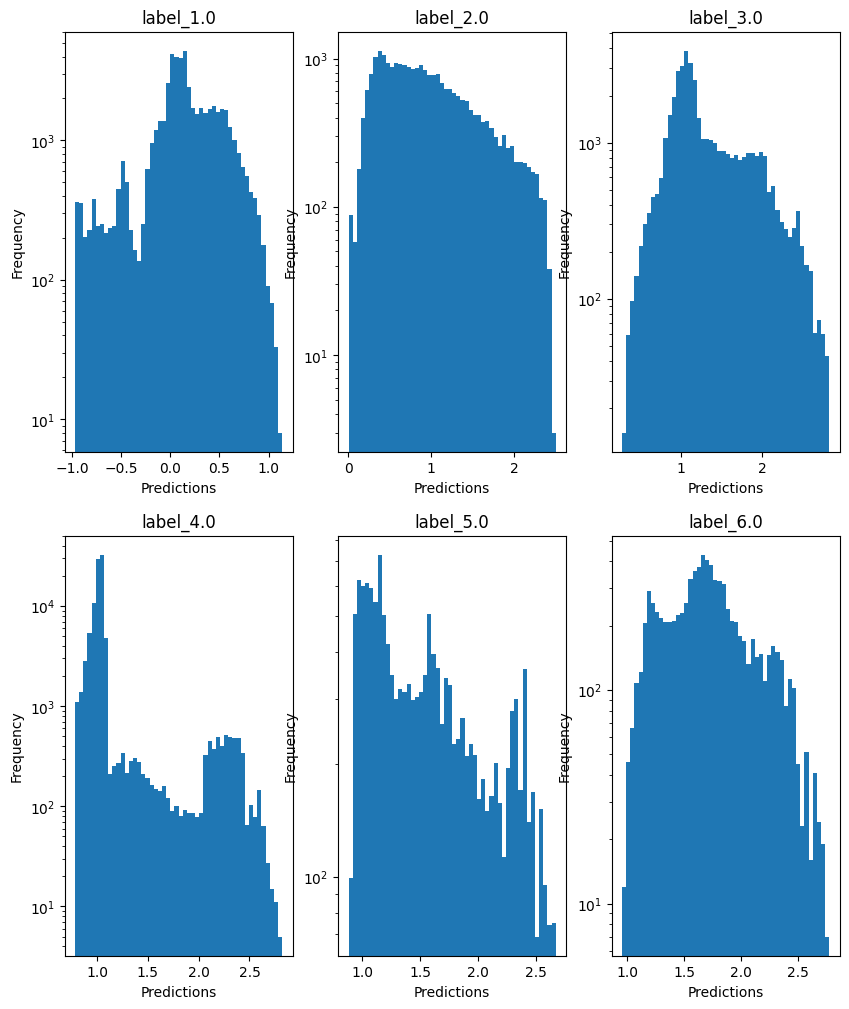

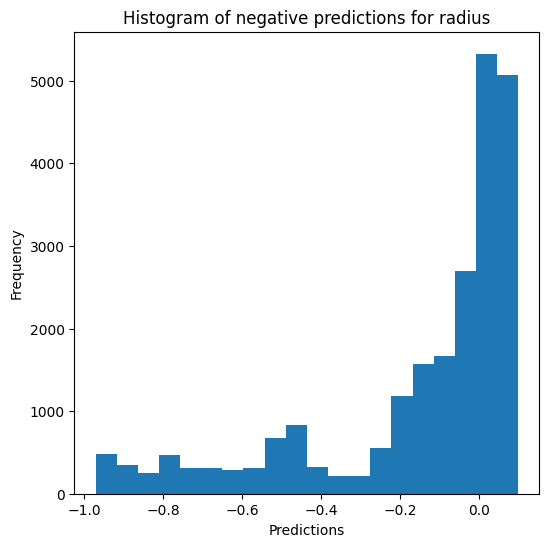

Saving predictions and results...


In [15]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### Random forests

In [16]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9998826179225381
  RMSE :  0.03269409540577149
  MAE :  0.008728006588199791
  MedAE :  0.00026000000000092616
  CORR :  0.9999413244237632
  MAX_ER :  0.7692199999999918
  Percentiles : 
    75th percentile :  0.003309999999999924
    90th percentile :  0.019320000000004
    95th percentile :  0.04482749999999791
    99th percentile :  0.1523915000000027

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9999728027365646
  RMSE :  0.017499450831235448
  MAE :  0.006884792163929803
  MedAE :  0.0005699999999850824
  CORR :  0.9999864635201366
  MAX_ER :  0.48635999999999946
  Percentiles : 
    75th percentile :  0.006779999999998565
    90th percentile :  0.021553000000002723
    95th percentile :  0.033726499999997085
    99th percentile :

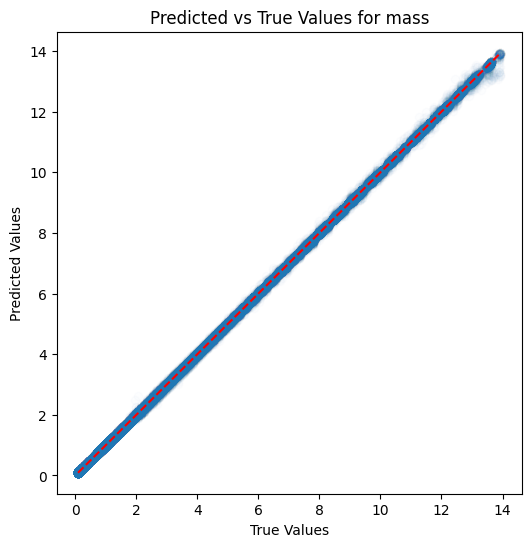

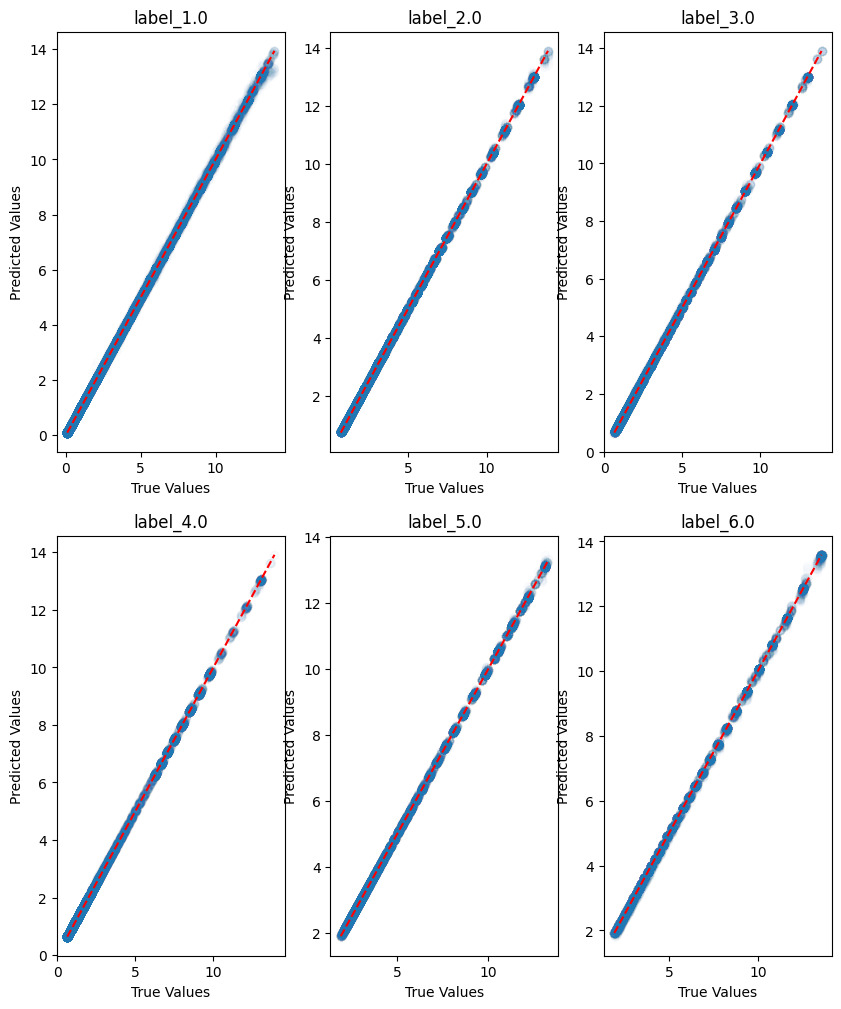

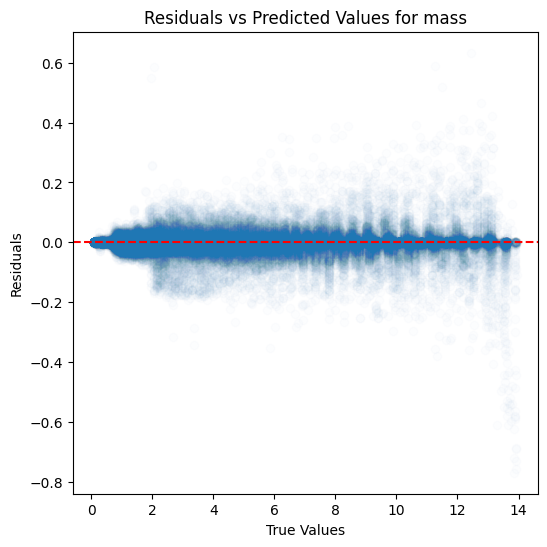

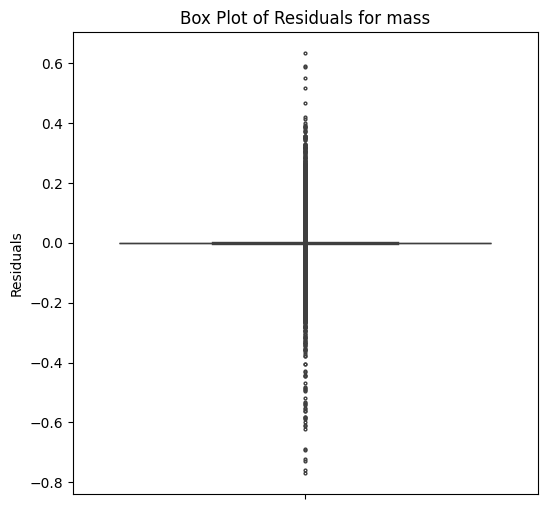

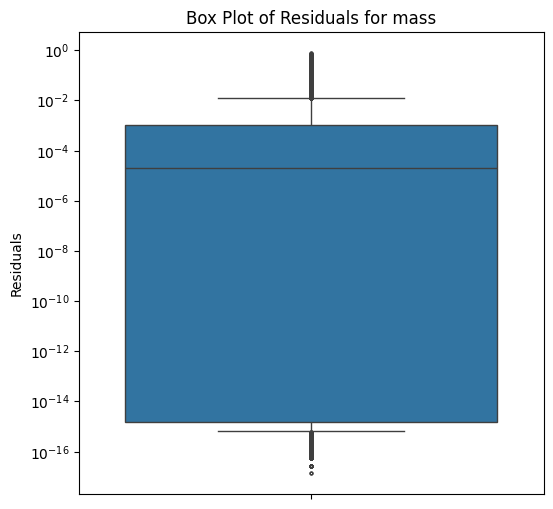

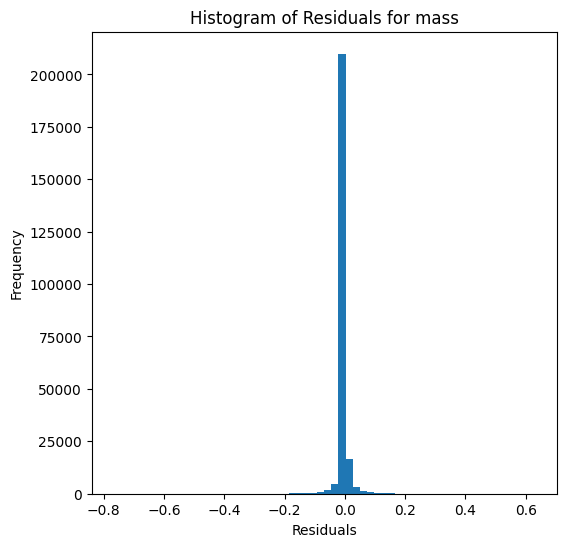

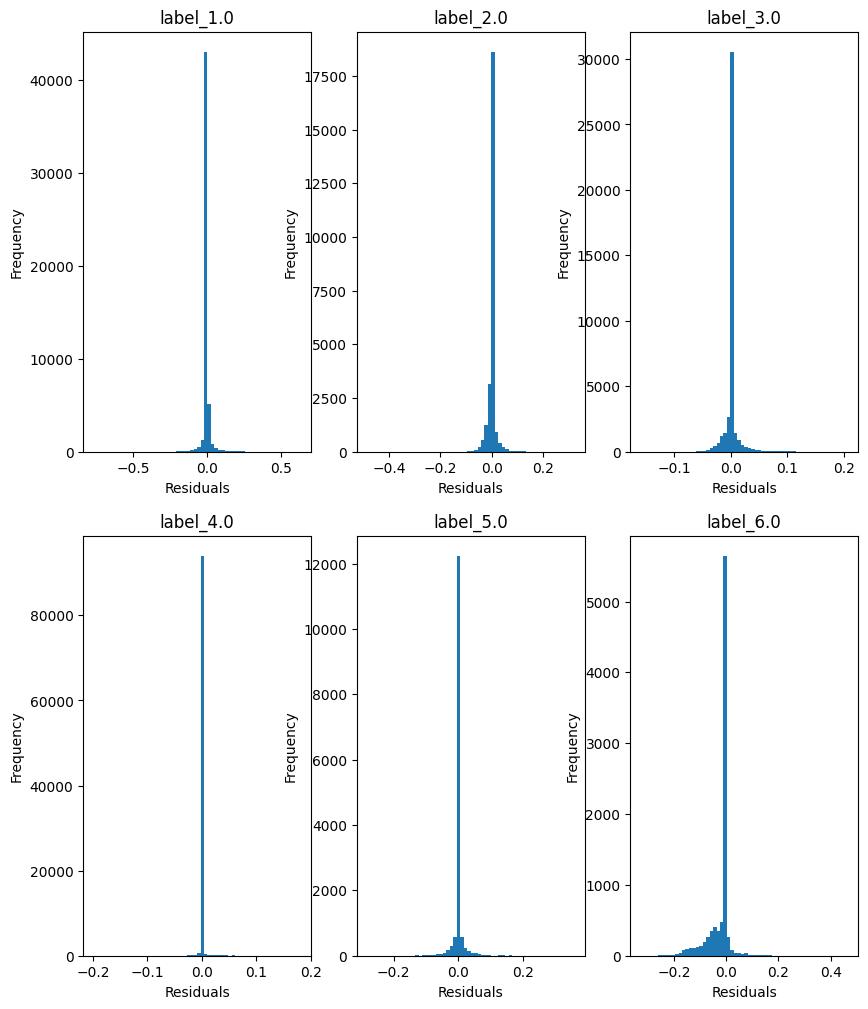

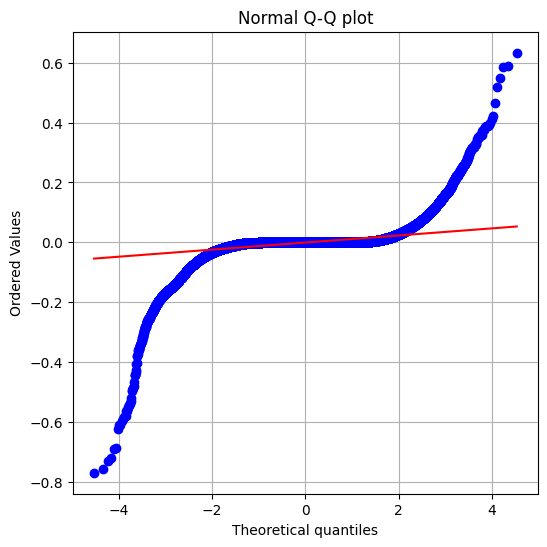

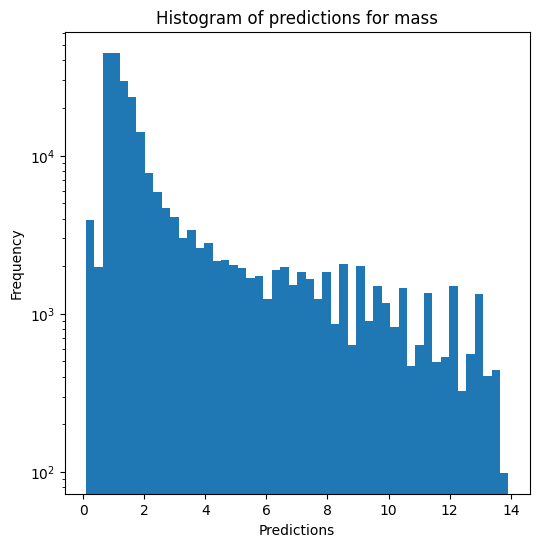

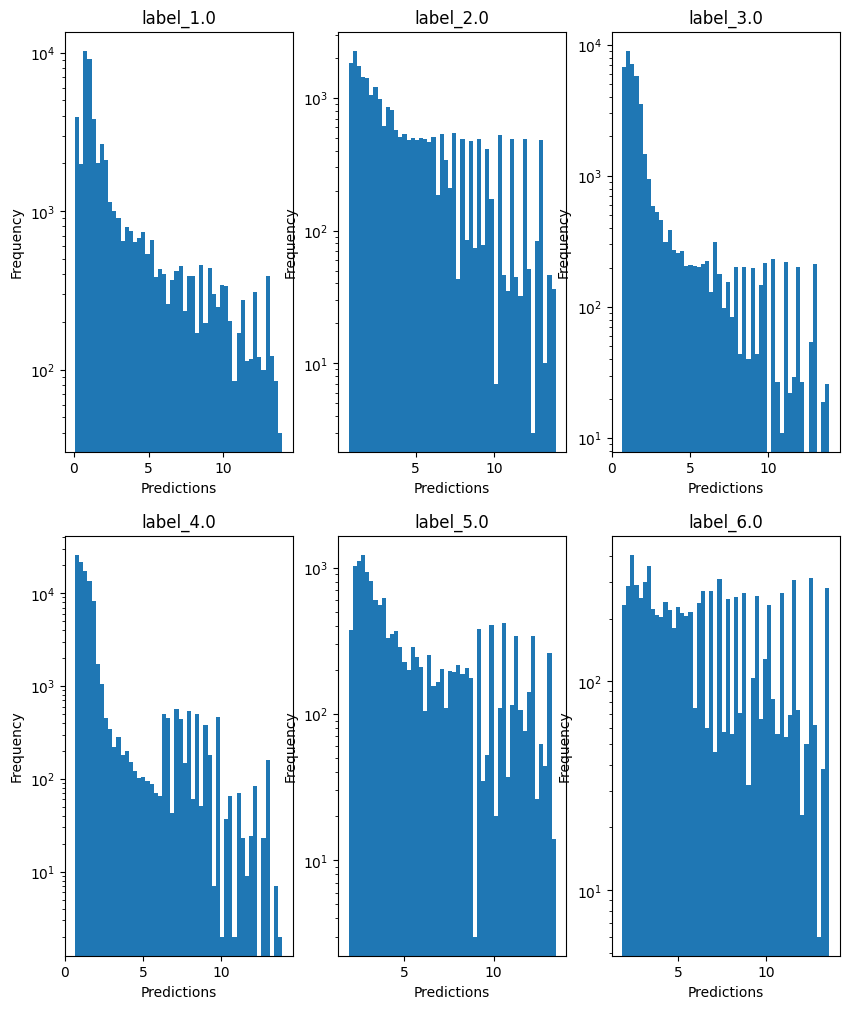

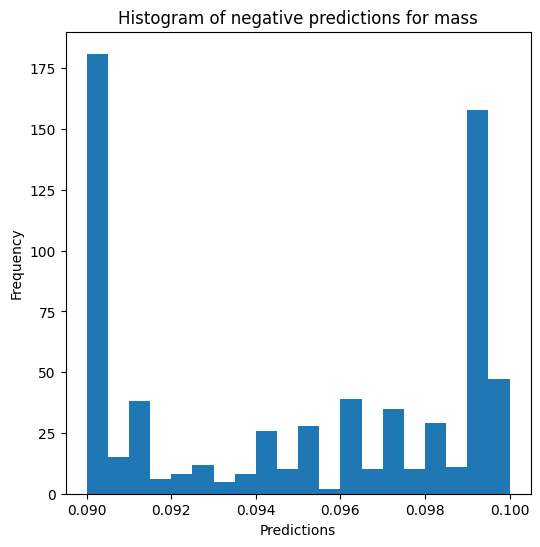


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9999192726864985
  RMSE :  0.003288873897279041
  MAE :  0.0013209096883598957
  MedAE :  0.0001805764865885351
  CORR :  0.9999596752280383
  MAX_ER :  0.0731352457576934
  Percentiles : 
    75th percentile :  0.001109365076771944
    90th percentile :  0.003972661761195734
    95th percentile :  0.006788609344399454
    99th percentile :  0.014510392245890154

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9997617016004685
  RMSE :  0.00837081901248598
  MAE :  0.00282207061186302
  MedAE :  0.0004502680367924894
  CORR :  0.999884997923097
  MAX_ER :  0.28472151633180687
  Percentiles : 
    75th percentile :  0.002669870181877698
    90th percentile :  0.007771794758503259
    95th percentile :  0.01201356241094511
    99th percentile :  0.02842107448437884

radius results for t

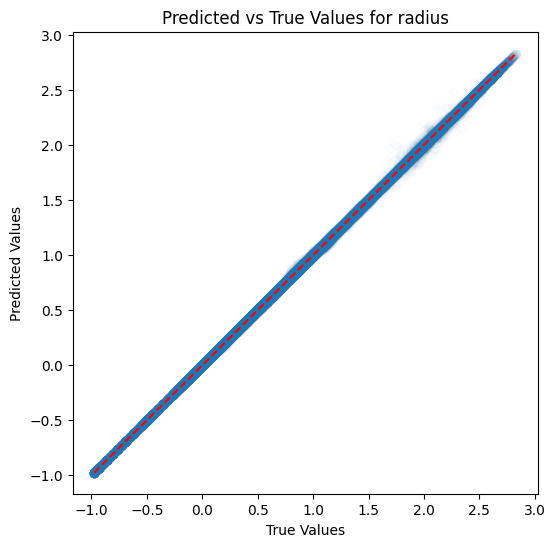

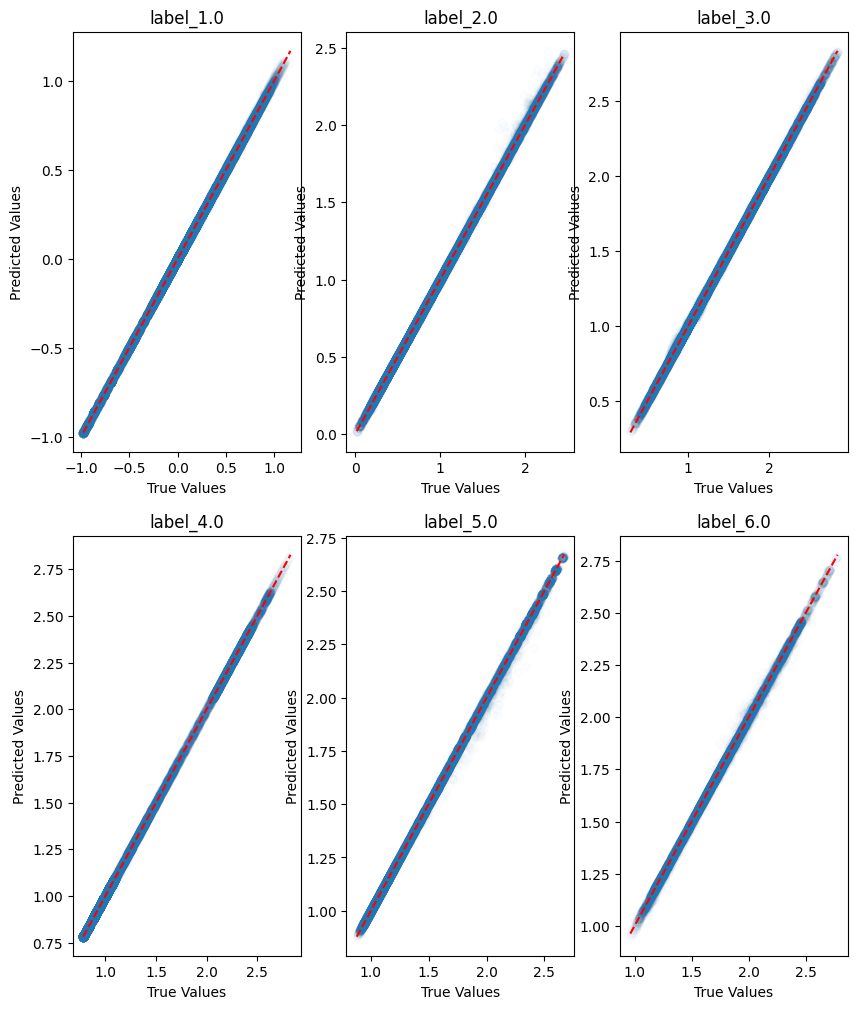

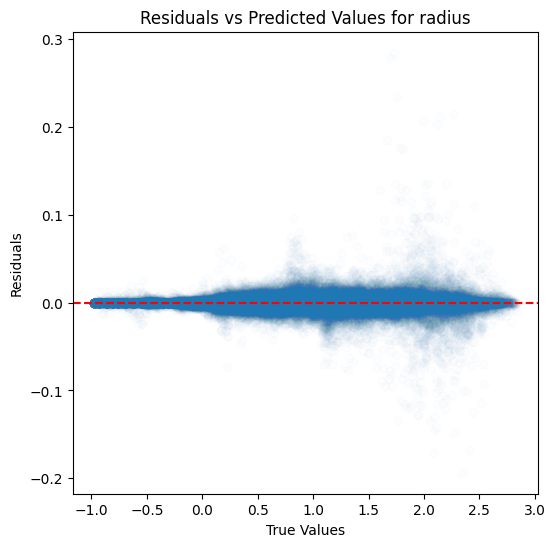

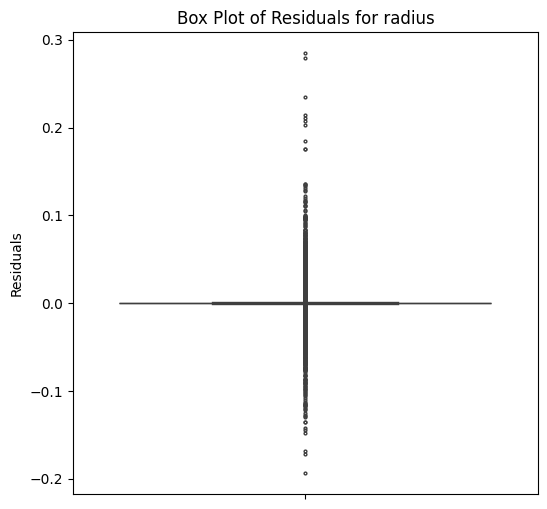

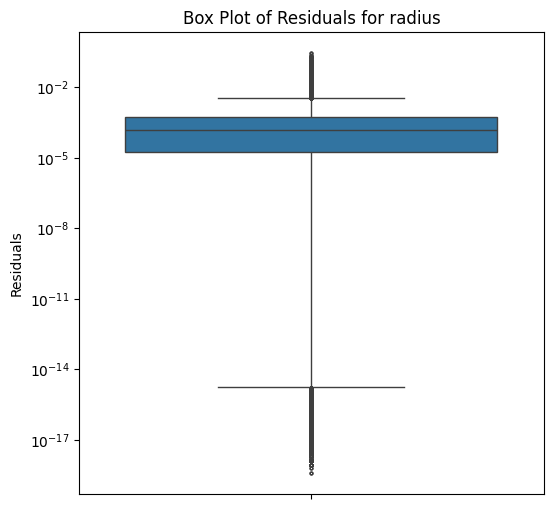

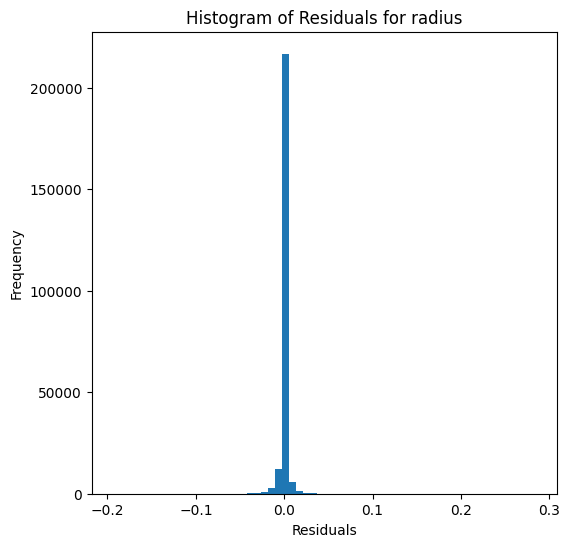

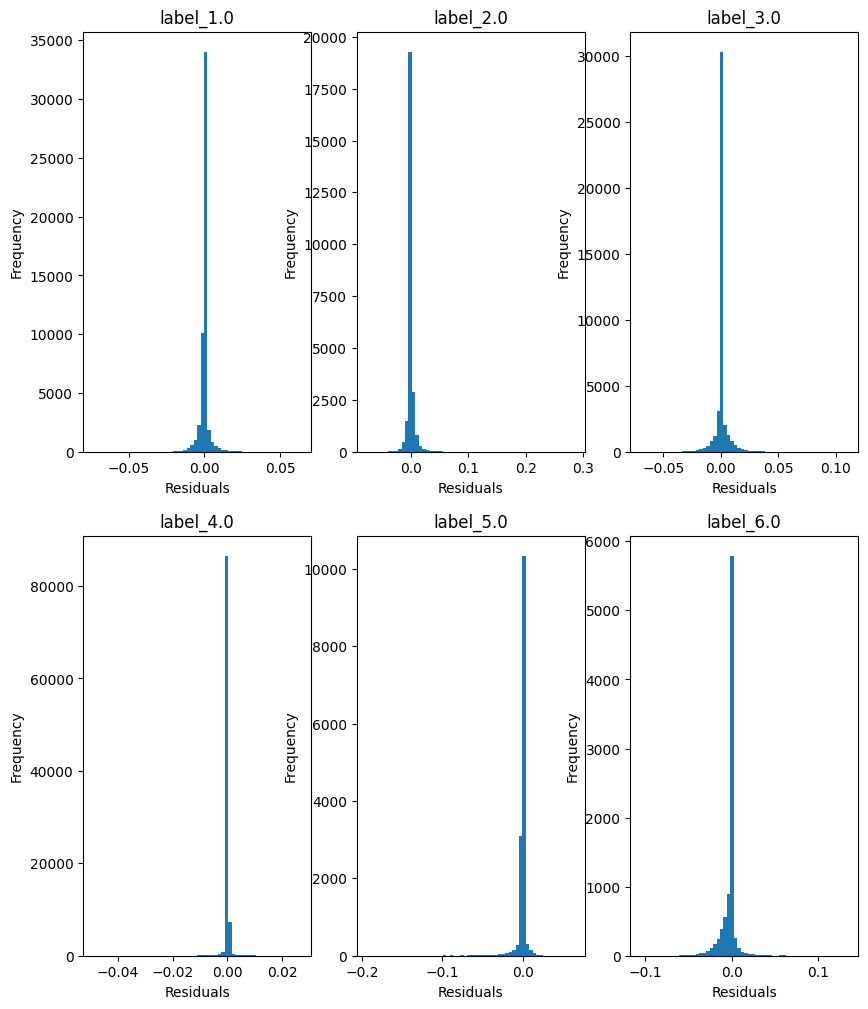

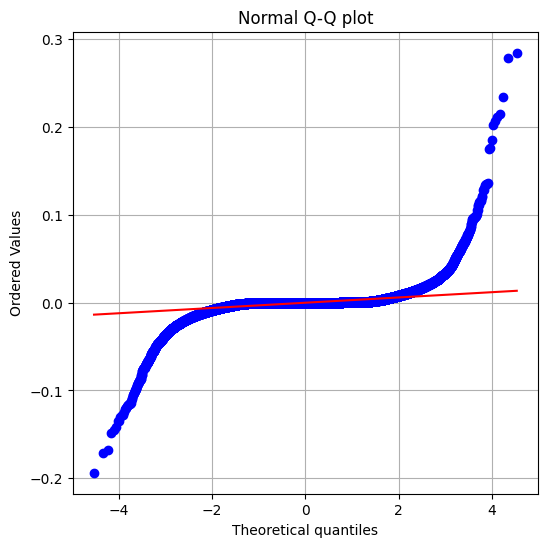

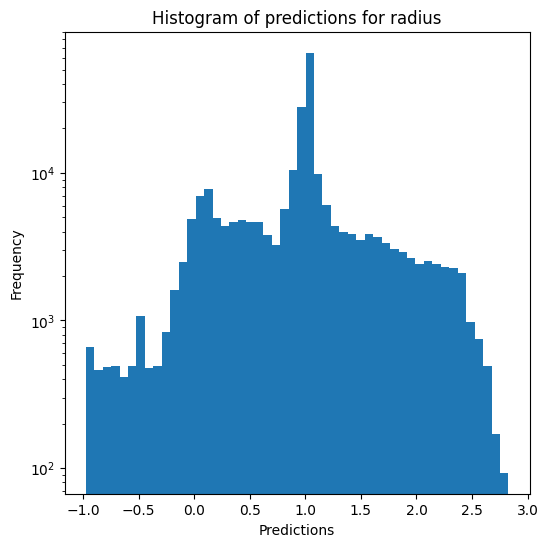

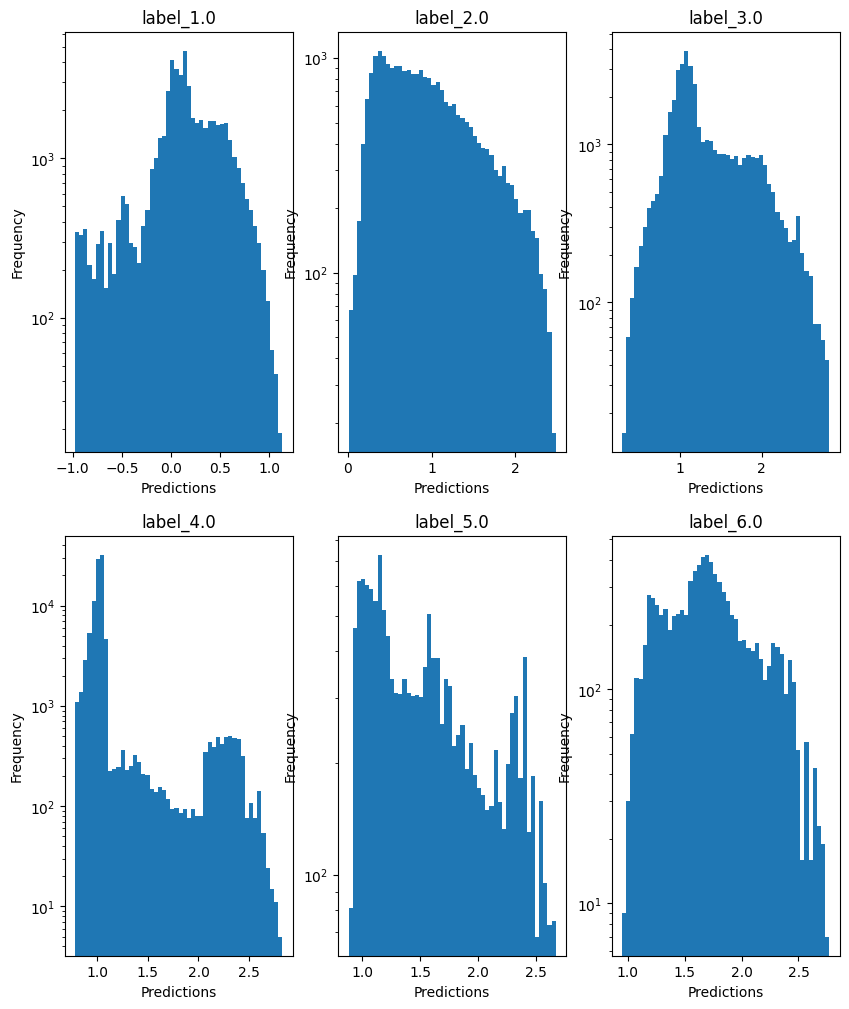

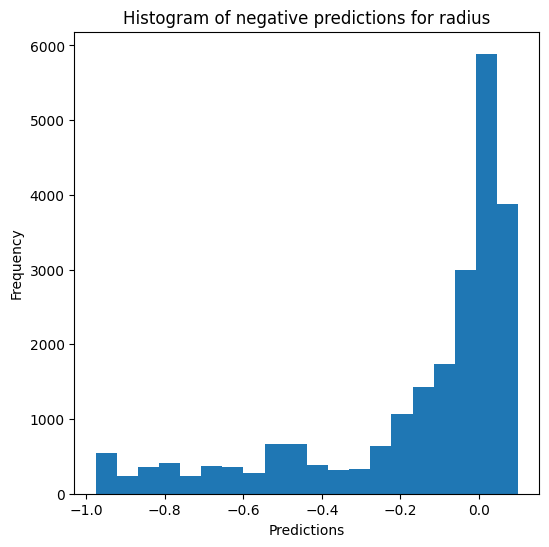

Saving predictions and results...


In [17]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)
# average depth de 44-46

### XGBoost

In [18]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9991350851722829
  RMSE :  0.0887554156625211
  MAE :  0.046886387633201056
  MedAE :  0.020626248836517425
  CORR :  0.999567813034968
  MAX_ER :  1.4695928878784184
  Percentiles : 
    75th percentile :  0.05201218032836952
    90th percentile :  0.11996983242034909
    95th percentile :  0.18982356643676757
    99th percentile :  0.37039495620727525

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.999888070822217
  RMSE :  0.03612342170599431
  MAE :  0.02399718580019451
  MedAE :  0.01514275693893452
  CORR :  0.9999466740441237
  MAX_ER :  0.3200783462524406
  Percentiles : 
    75th percentile :  0.031249127388000564
    90th percentile :  0.05624012413024876
    95th percentile :  0.07732287445068352
    99th percentile :  0.129936

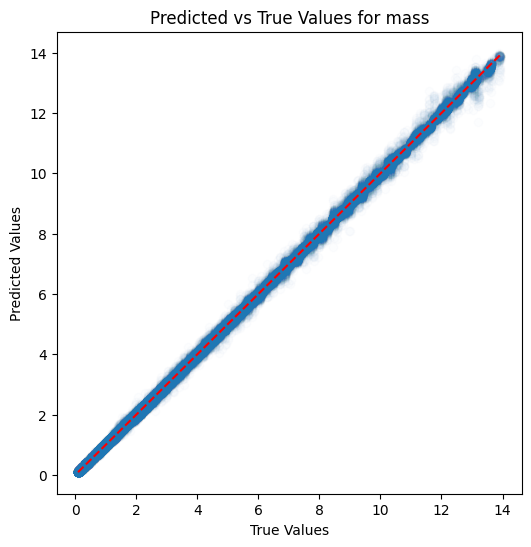

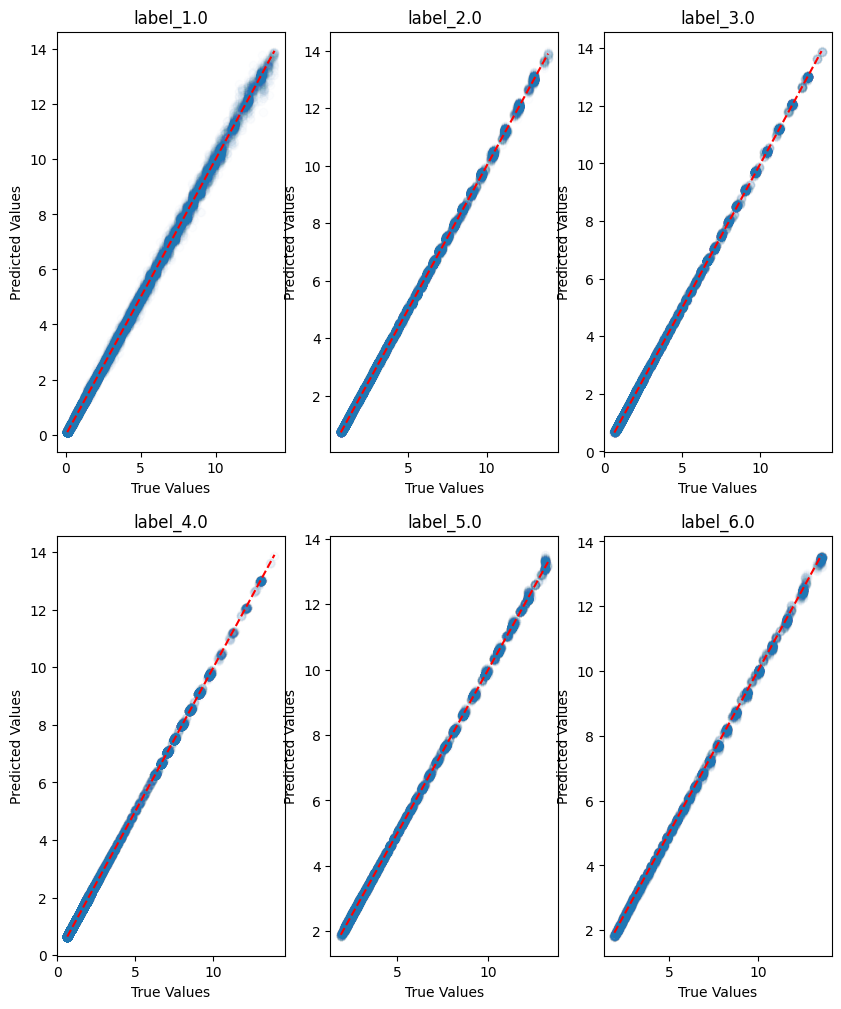

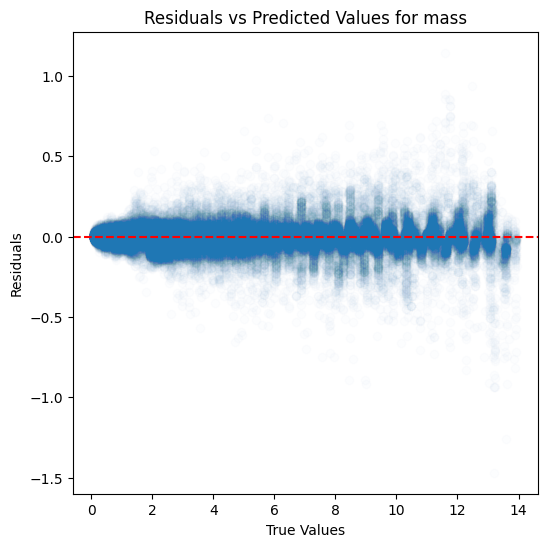

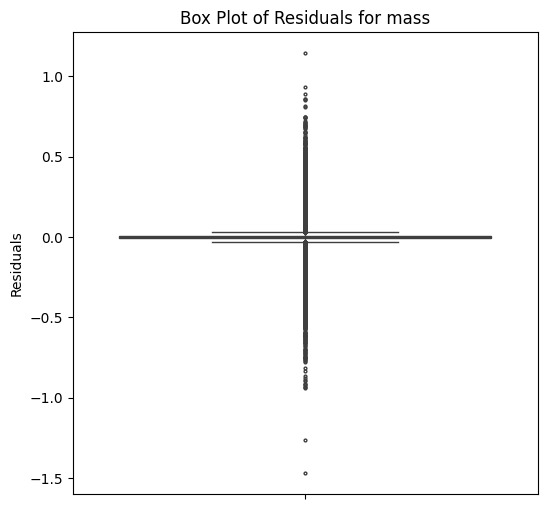

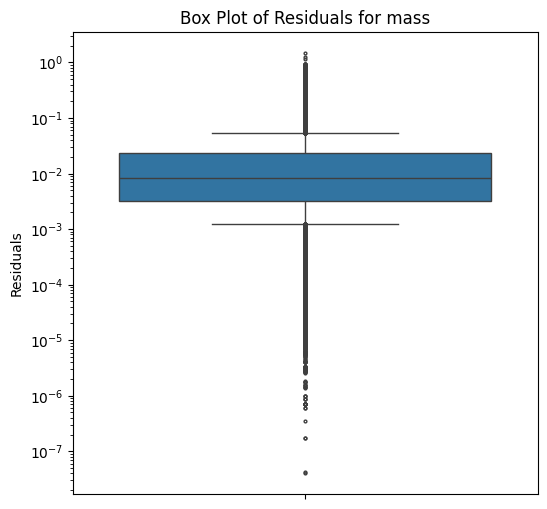

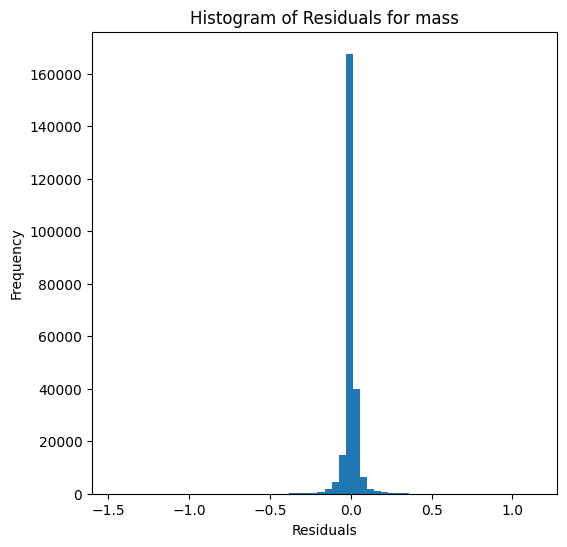

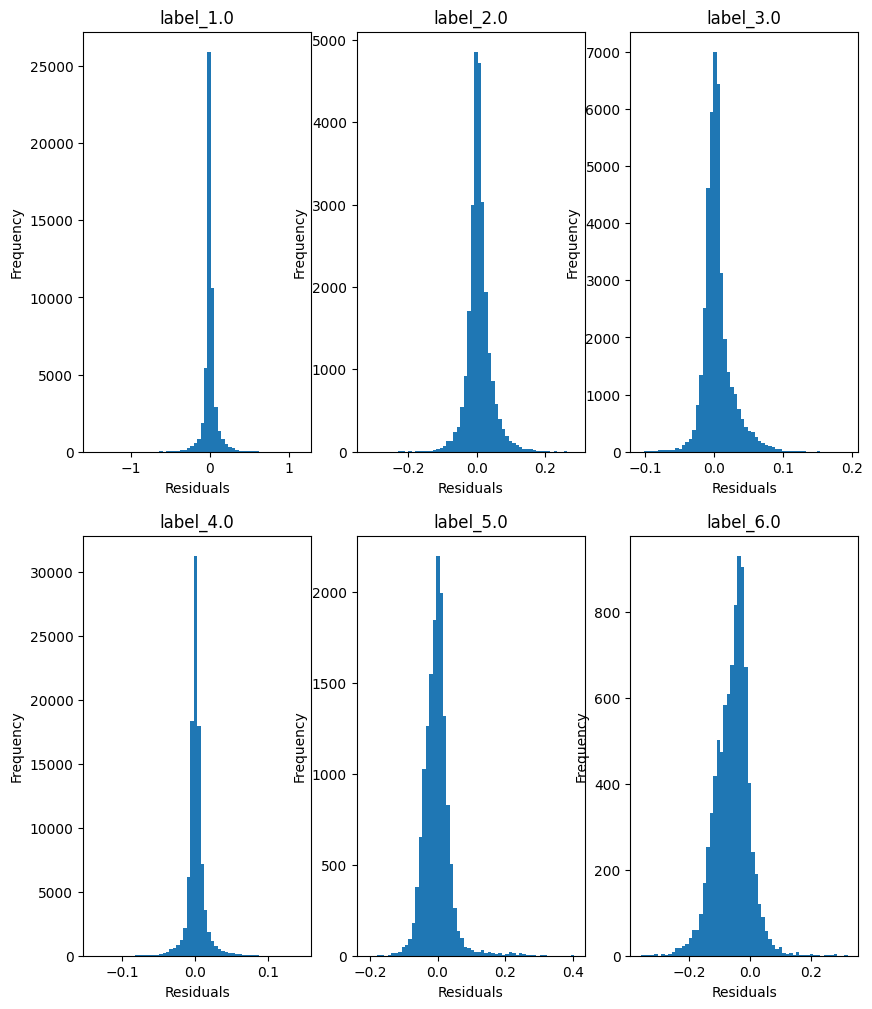

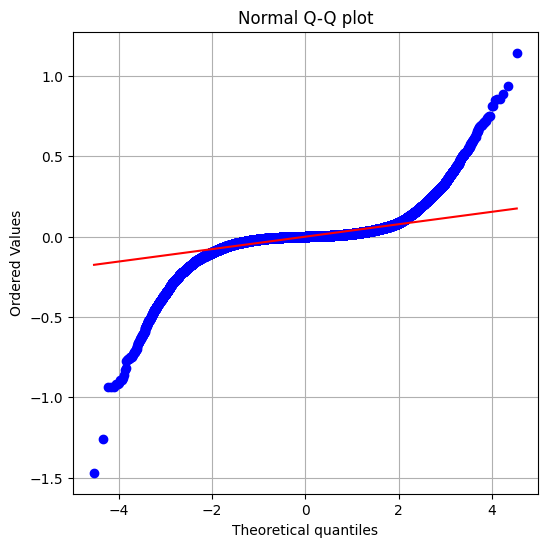

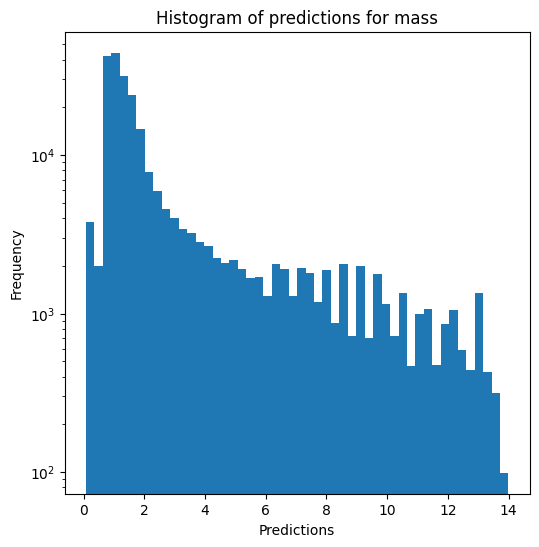

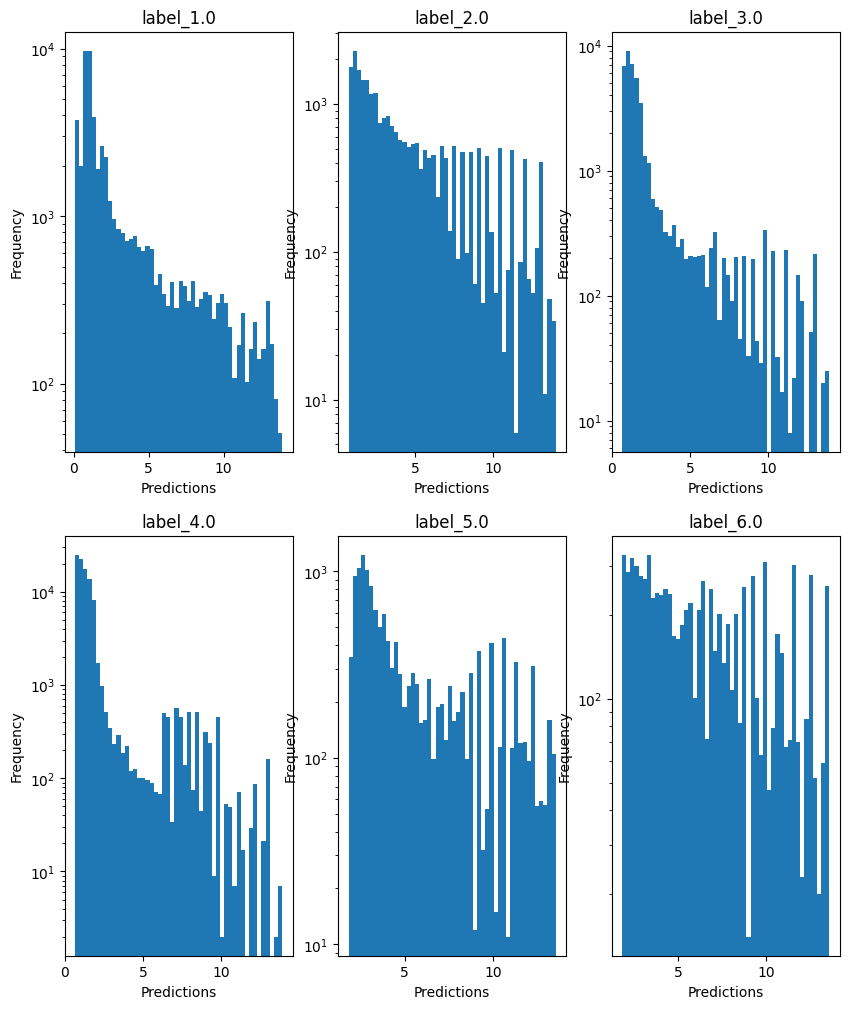

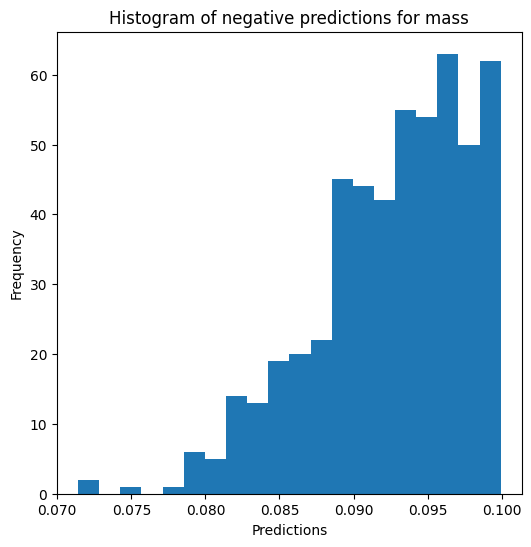


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.99924952821124
  RMSE :  0.010025829454064671
  MAE :  0.006851980137943696
  MedAE :  0.004714362388504166
  CORR :  0.9996247501188131
  MAX_ER :  0.08896295685255406
  Percentiles : 
    75th percentile :  0.009184591126604955
    90th percentile :  0.015166520496588815
    95th percentile :  0.02010547089875027
    99th percentile :  0.03502351341217506

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9994404577145701
  RMSE :  0.01284990524417628
  MAE :  0.009512662463685836
  MedAE :  0.007496822958309862
  CORR :  0.9997269256609371
  MAX_ER :  0.15352155580429705
  Percentiles : 
    75th percentile :  0.013189632936975615
    90th percentile :  0.019703675985482158
    95th percentile :  0.024772533746863855
    99th percentile :  0.03776110700516406

radius results for the 

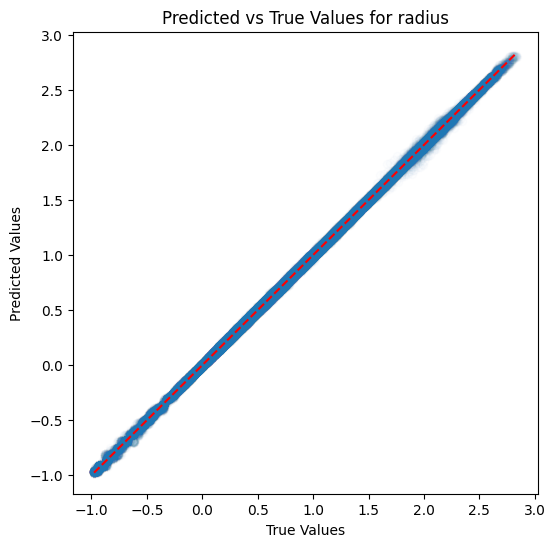

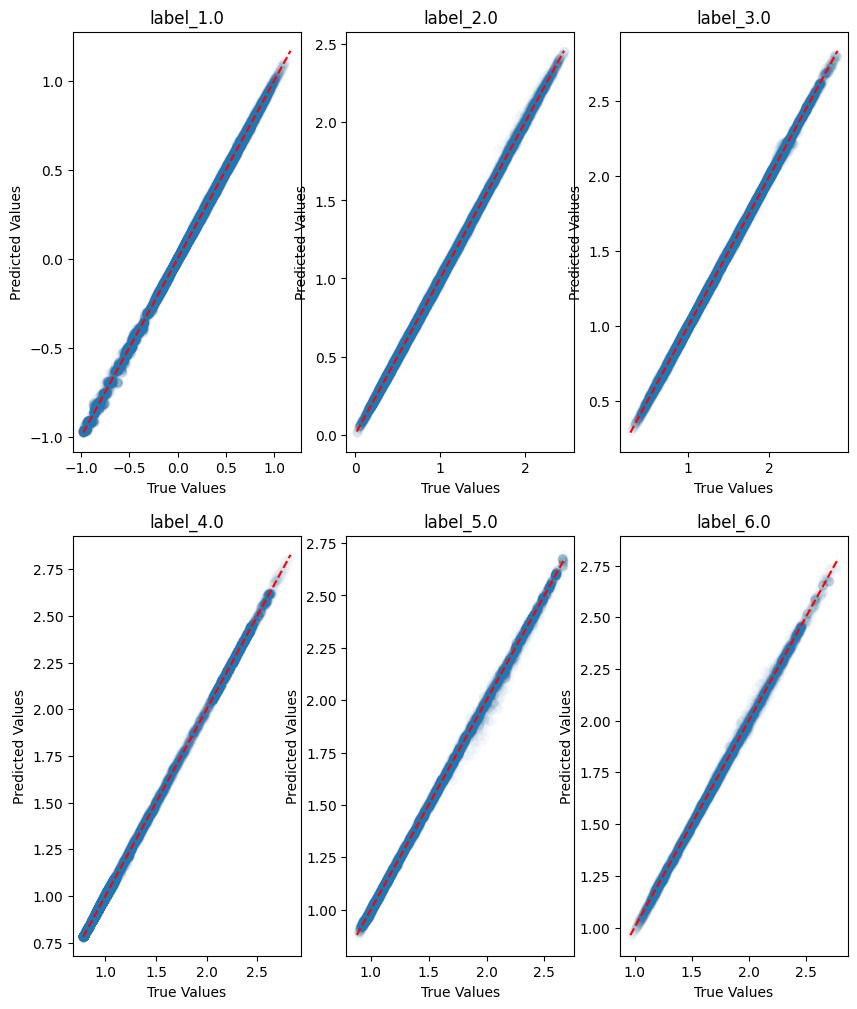

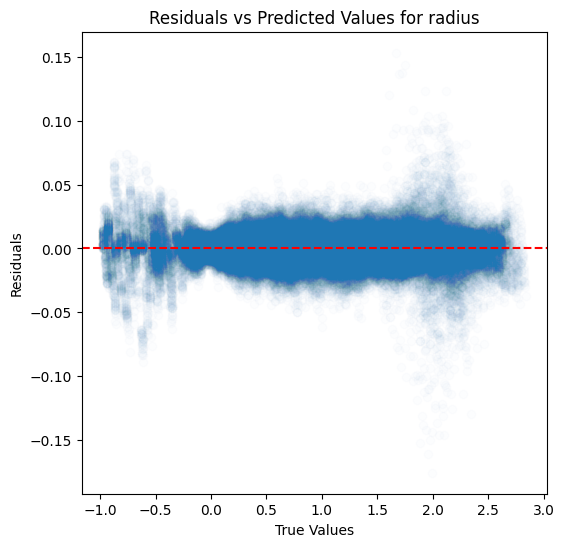

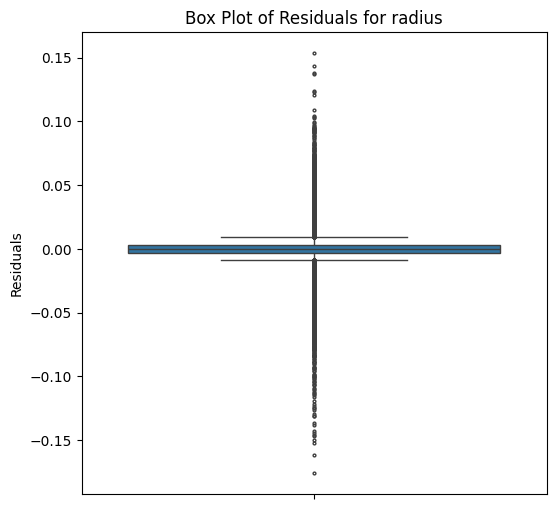

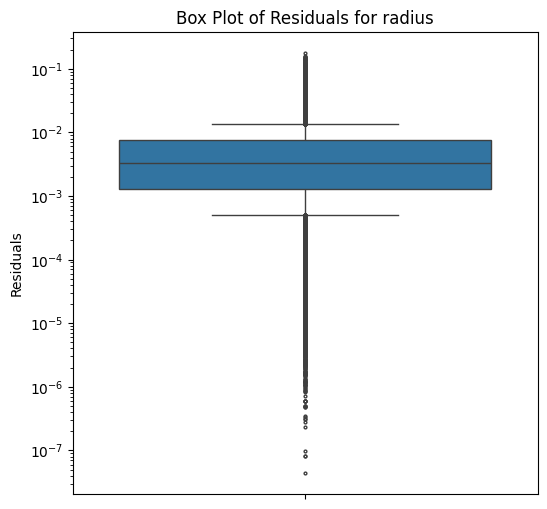

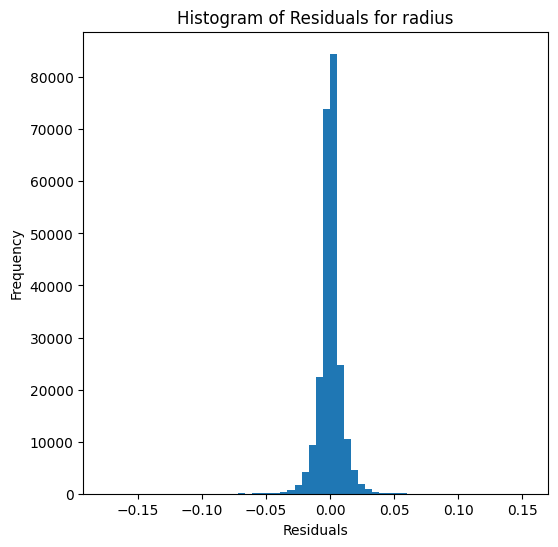

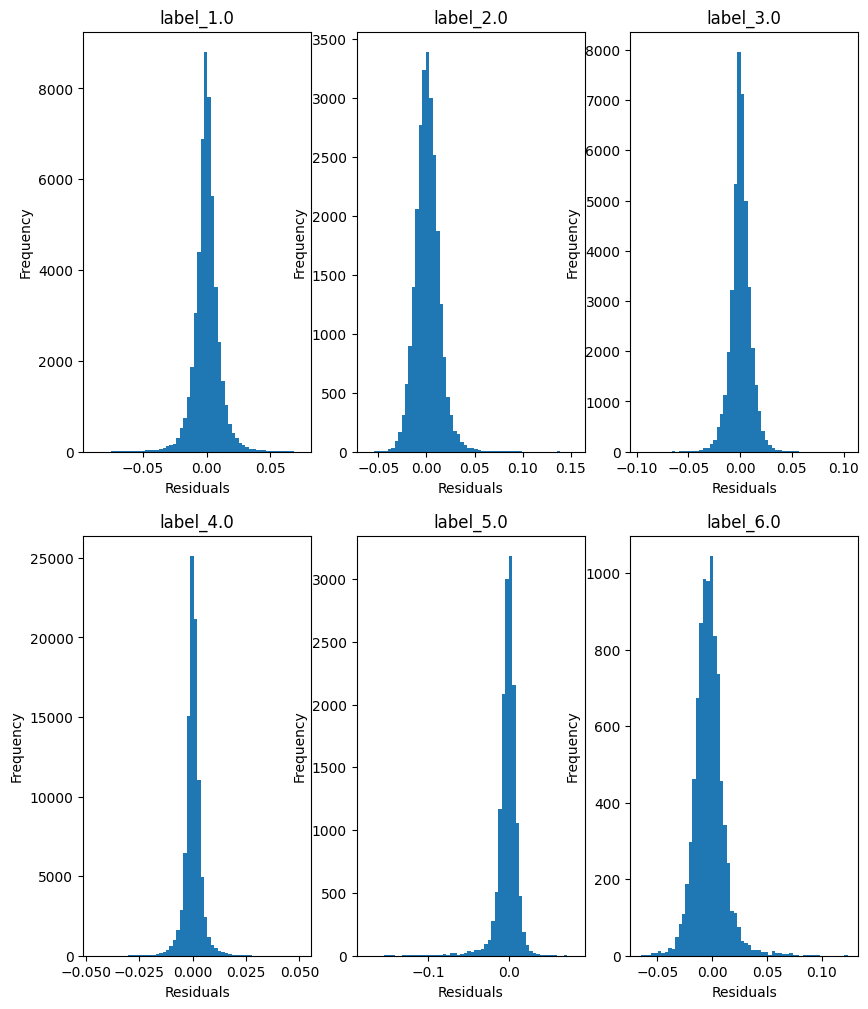

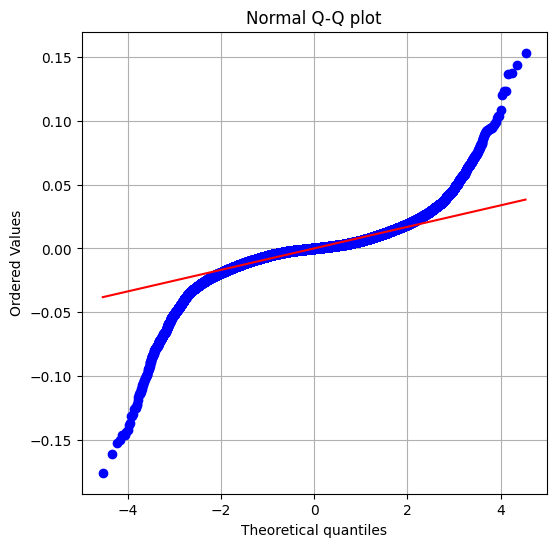

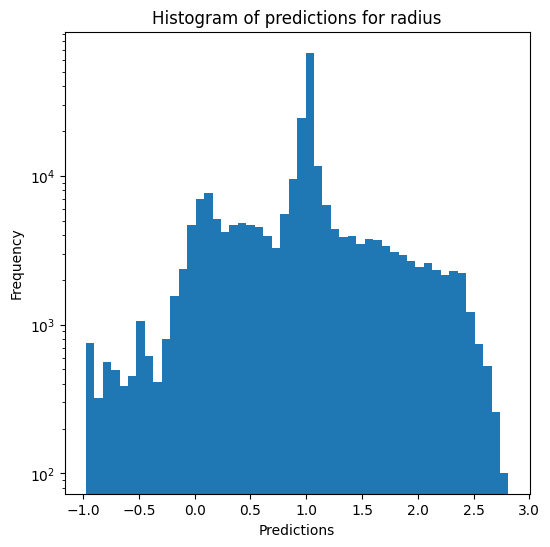

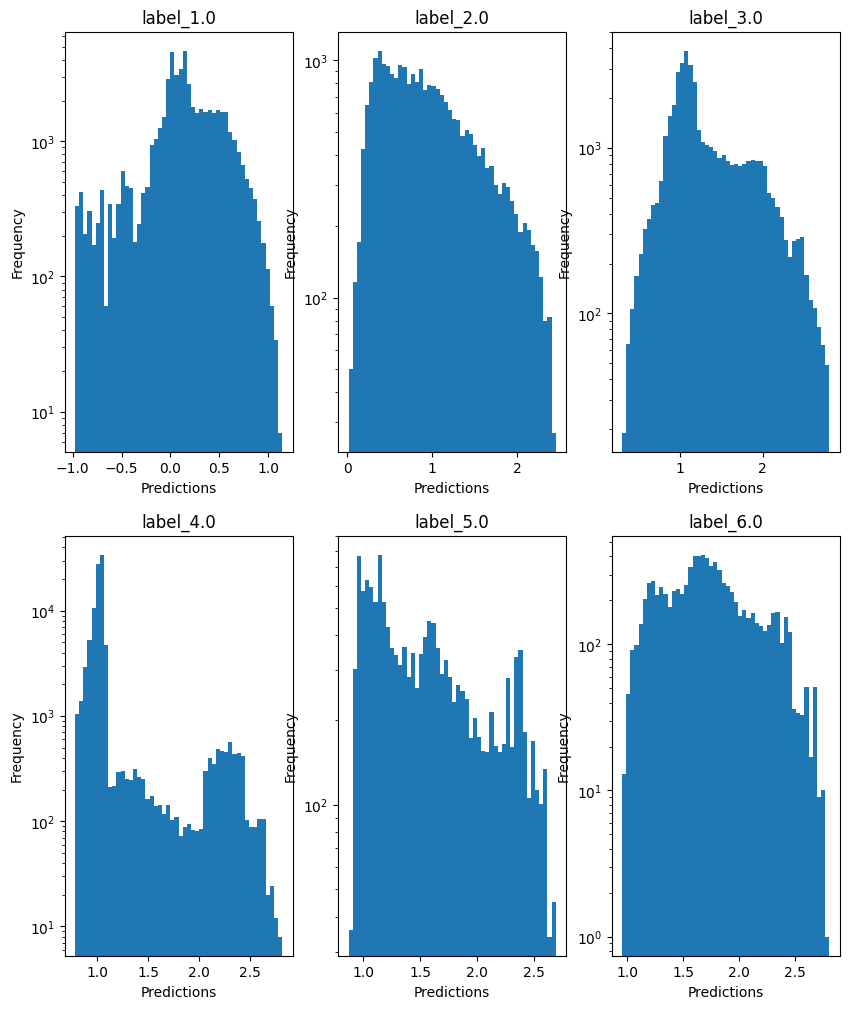

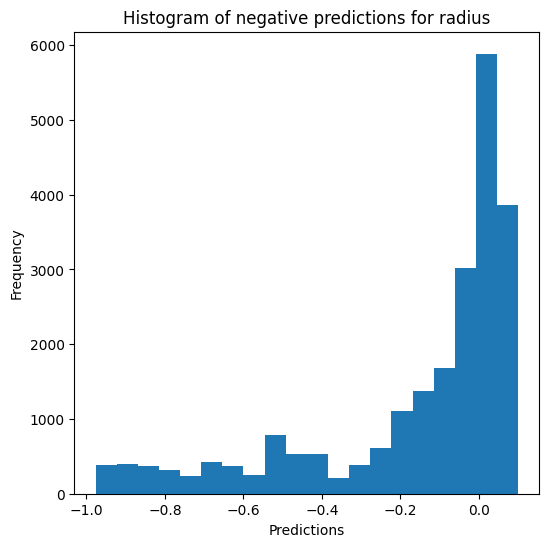

Saving predictions and results...


In [19]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)

### Multi-layer perceptron

In [20]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power train data :
Performing K-fold...
Split 1 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.0022885440942784045
2 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.0023340118193431155
3 

...

0.0022238784519822215
4 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.002579429003622167
5 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.0021368109301361285

Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9972047986529854
  RMSE :  0.15978679417578714
  MAE :  0.0761734853084527
  MedAE :  0.025540347753858272
  CORR :  0.9986679182872662
  MAX_ER :  2.9624841577735594
  Percentiles : 
    75th percentile :  0.07265585423623441
    90th percentile :  0.22241515389971755
    95th percentile :  0.3330766347825768
    99th percentile :  0.6420637387344375

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9991489589185395
  RMSE :  0.10153297769963336
  MAE :  0.060275995226774855
  MedAE :  0.029789091655175293
  CORR :  0.9996136779310532
  MAX_ER :  0.7373214835906658
  Percentiles : 
    75th percentile :  0.07345808836416656
    90th percentile :  0.1536783171019418
    95th percentile :  0.22410399972893896
    99th percentile :  0.40903261227889004

mass results for the label category with

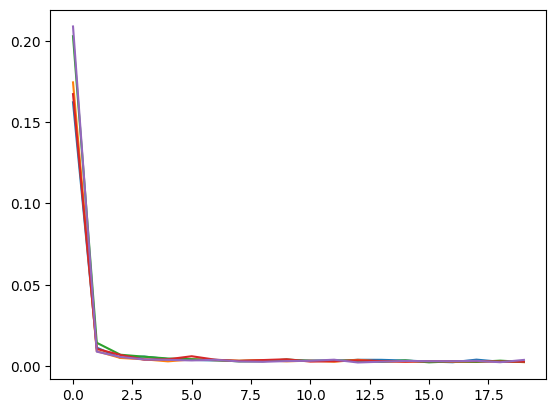

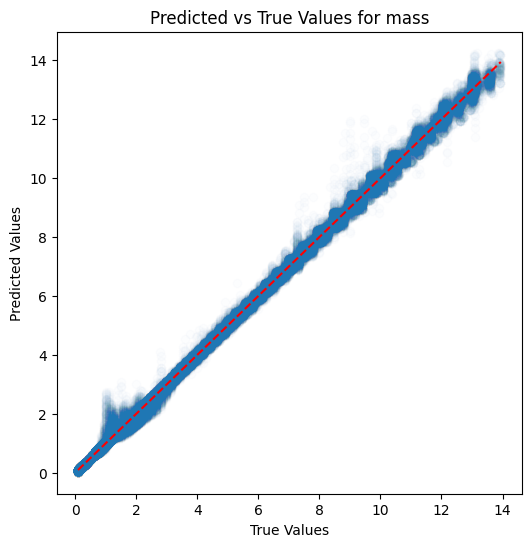

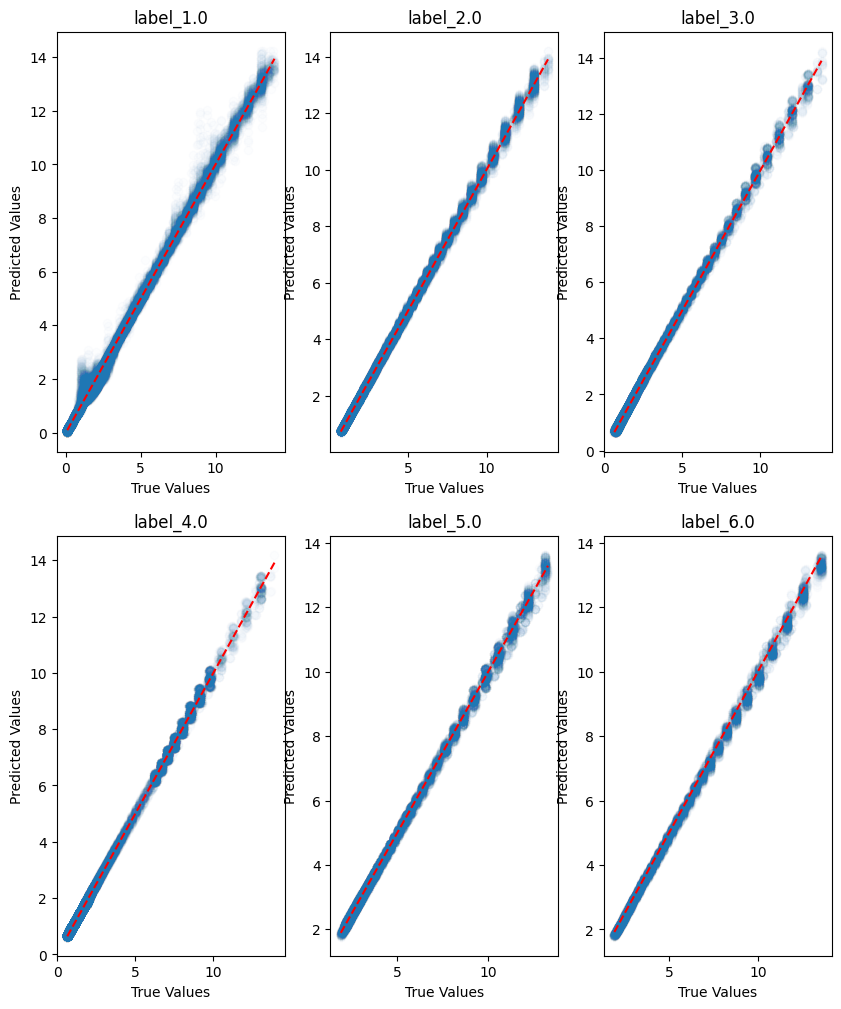

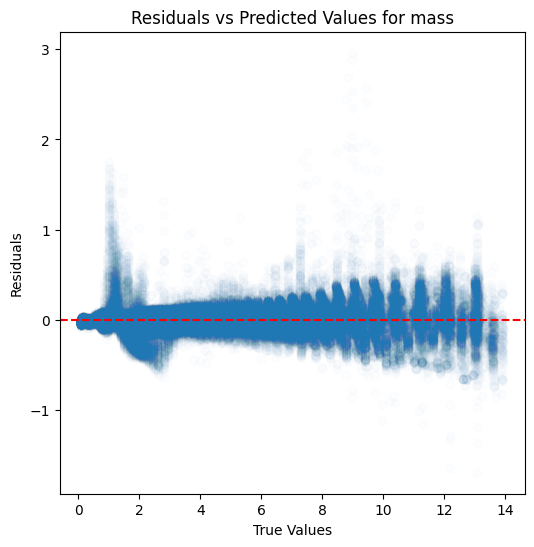

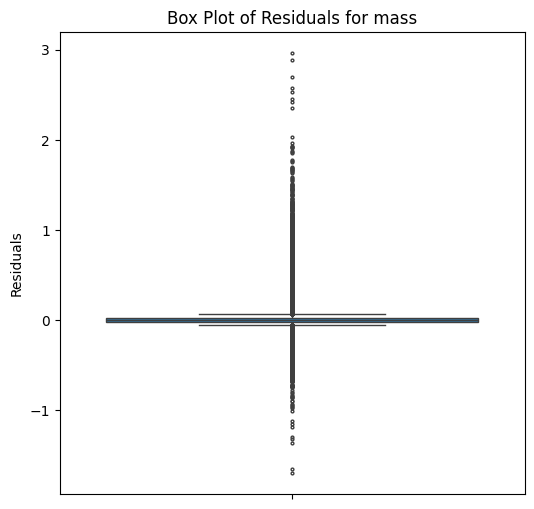

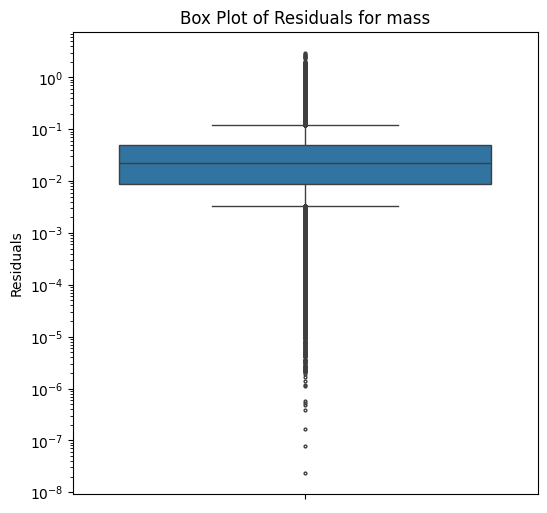

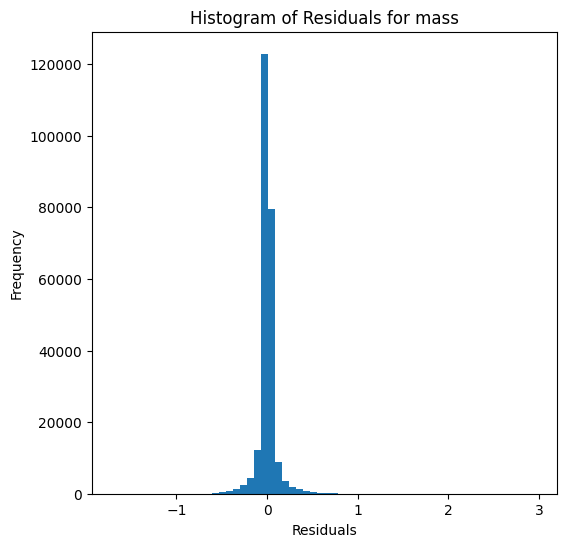

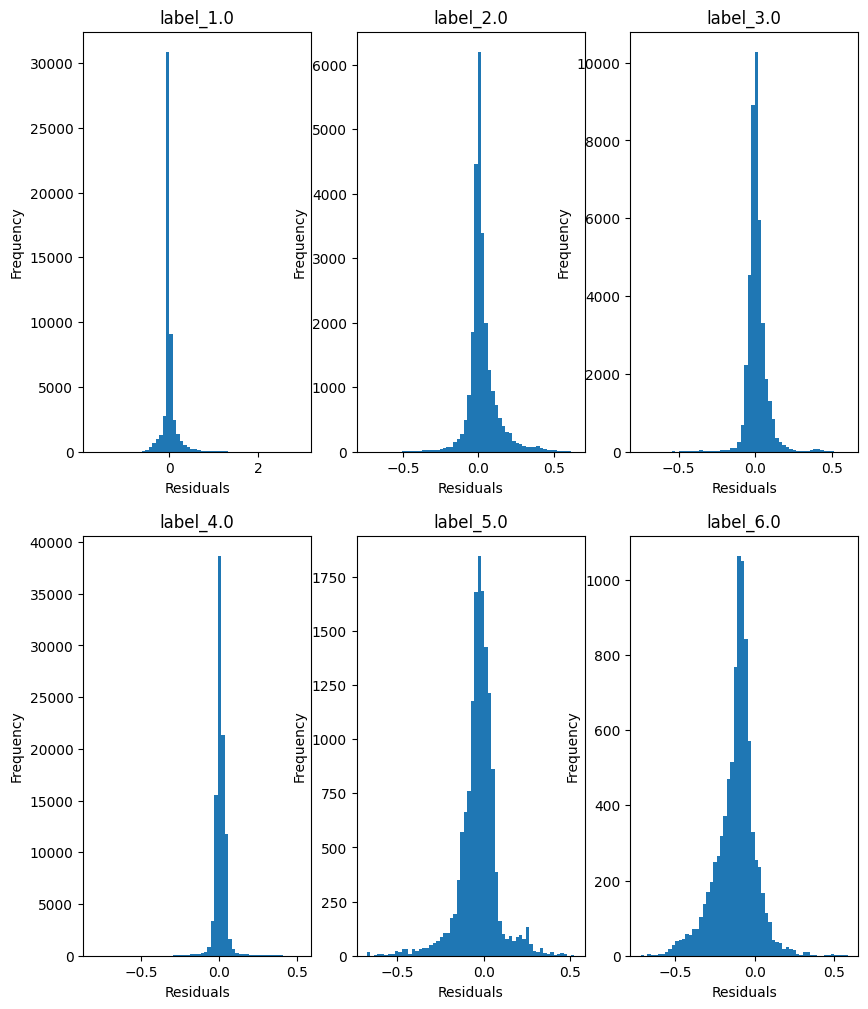

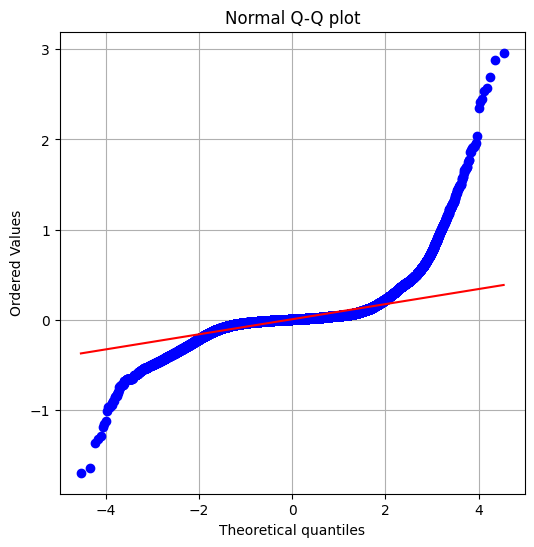

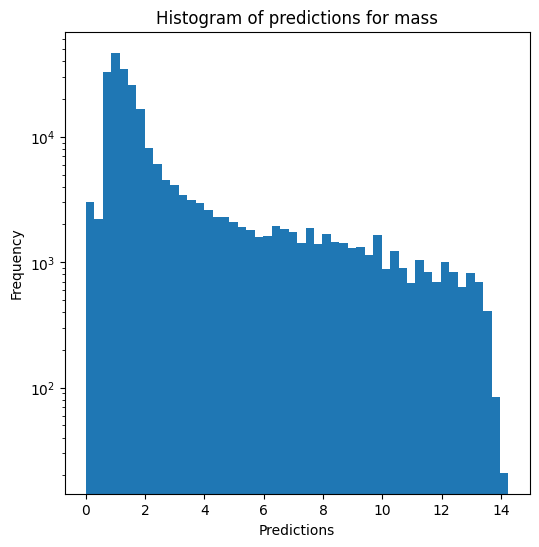

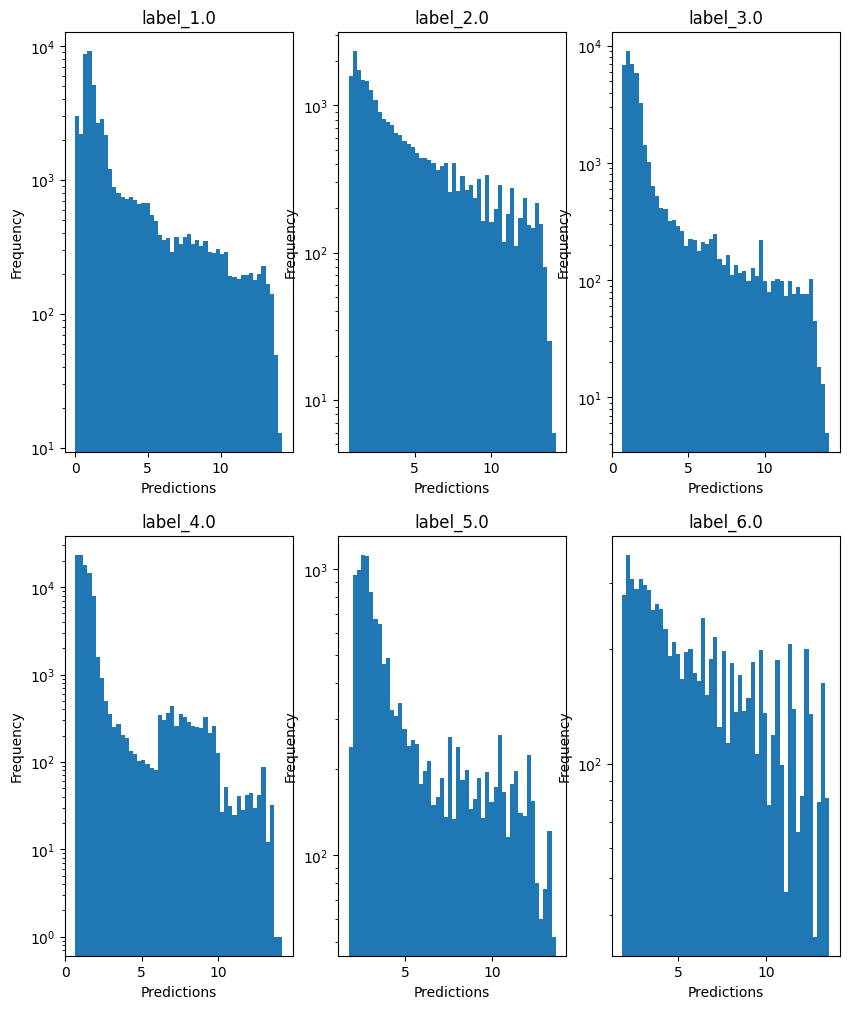

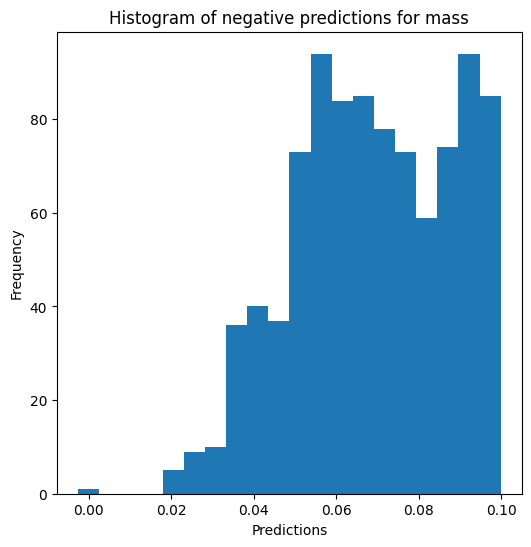


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9974935433163132
  RMSE :  0.018506713320370766
  MAE :  0.011627878502327643
  MedAE :  0.007665664990957633
  CORR :  0.9987483432923873
  MAX_ER :  0.2313755819959587
  Percentiles : 
    75th percentile :  0.01422150239269443
    90th percentile :  0.02509934996942946
    95th percentile :  0.03754658977923152
    99th percentile :  0.06448330238113822

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9992175904420176
  RMSE :  0.015156122053017073
  MAE :  0.010864240324090385
  MedAE :  0.008212553969707326
  CORR :  0.9996683382145478
  MAX_ER :  0.0970716137069032
  Percentiles : 
    75th percentile :  0.01445232429924706
    90th percentile :  0.022149255357459558
    95th percentile :  0.029725629723514755
    99th percentile :  0.055832575245519364

radius results for the l

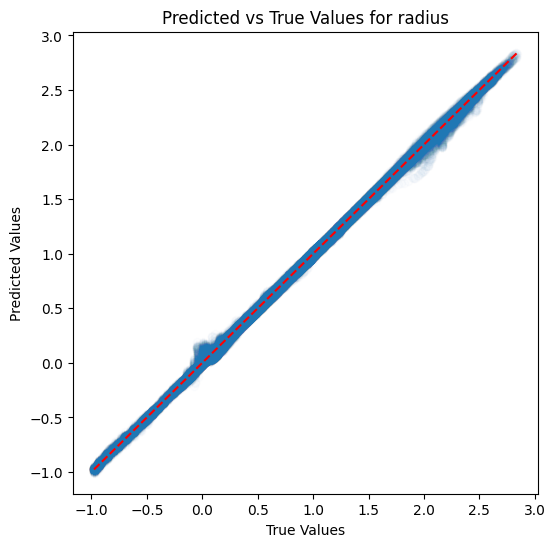

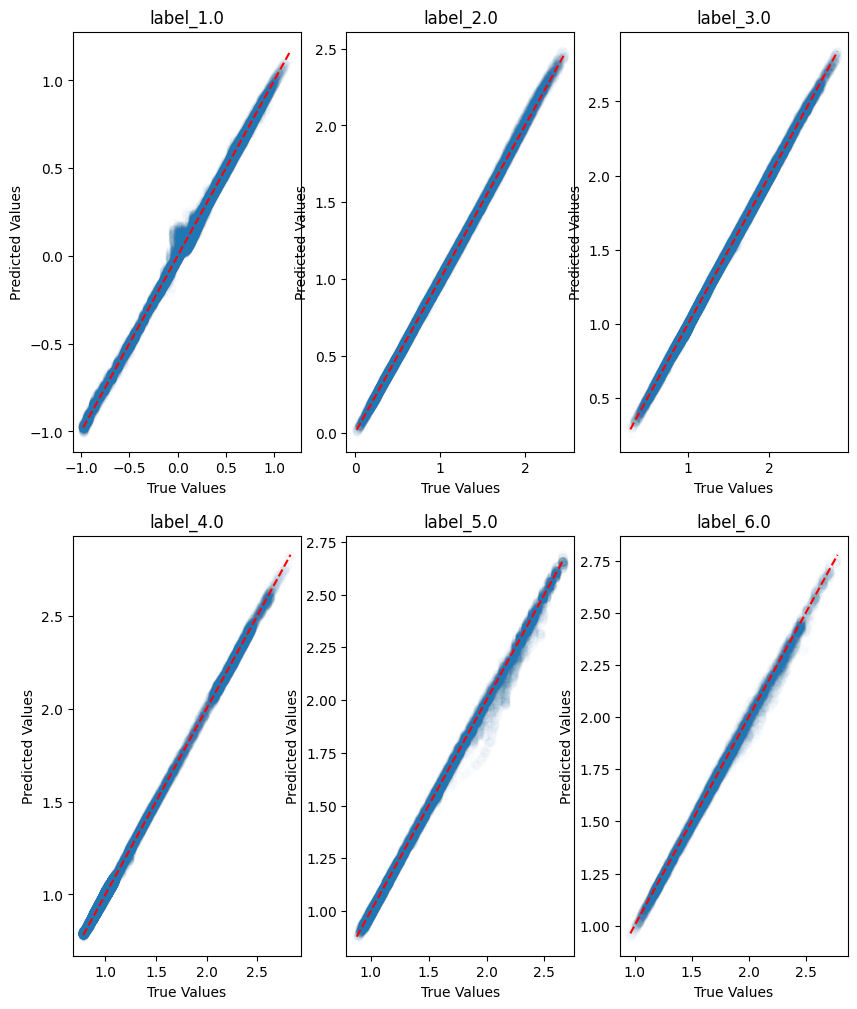

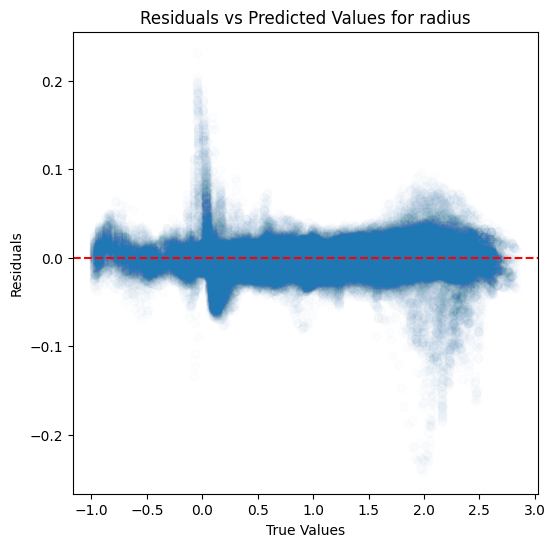

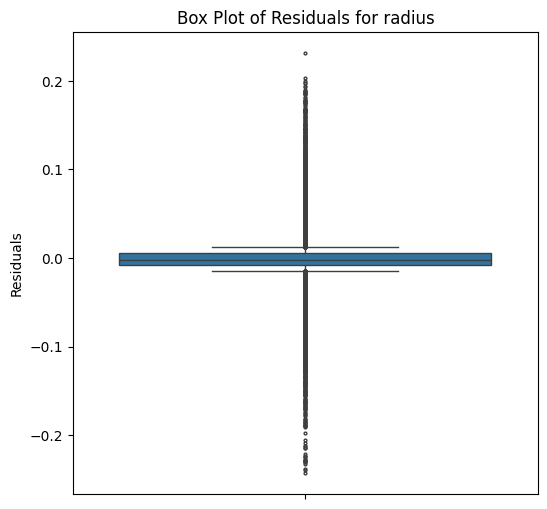

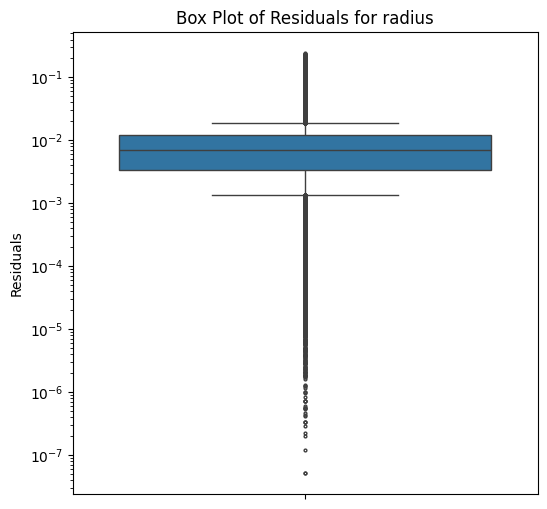

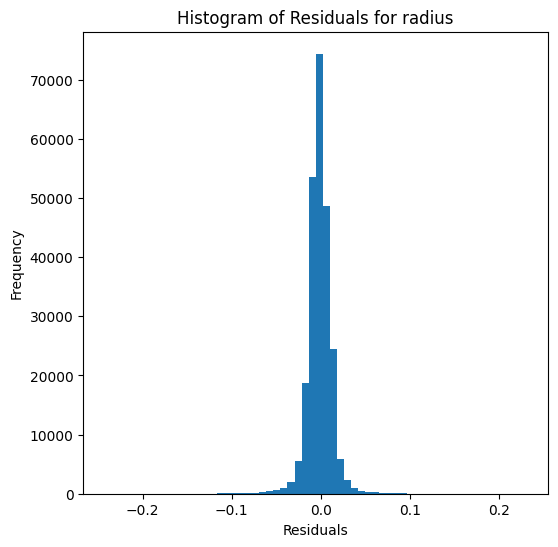

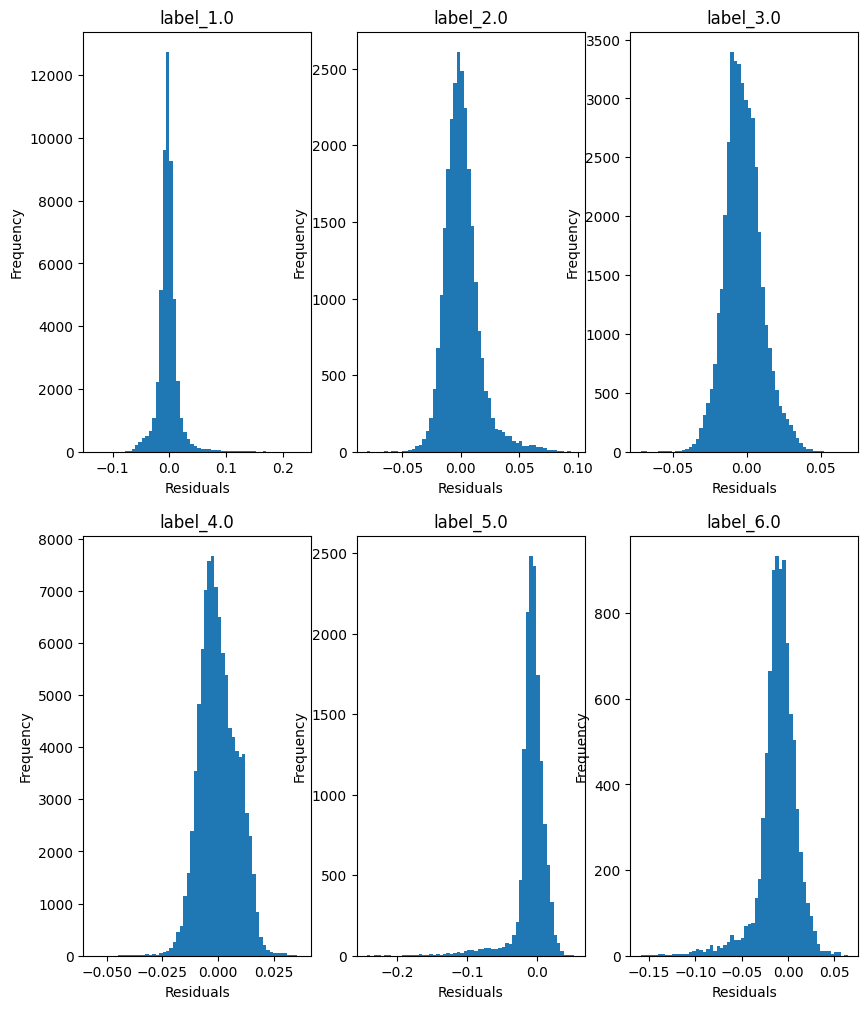

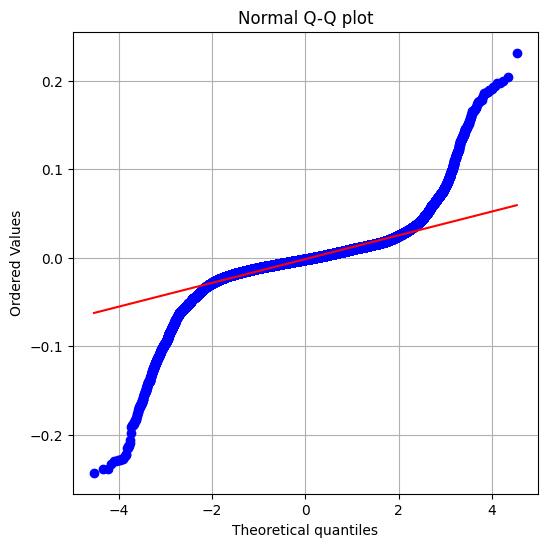

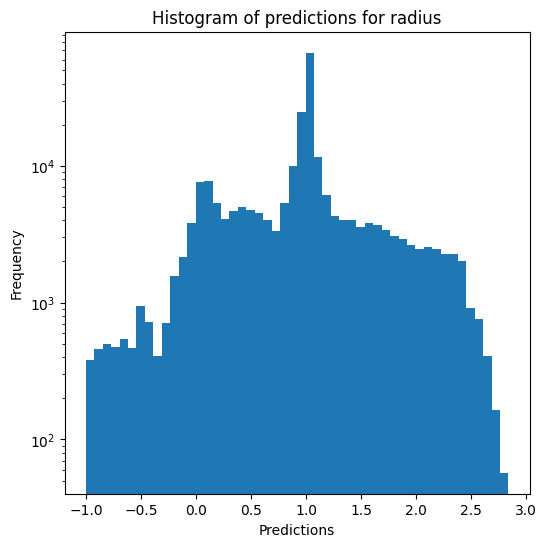

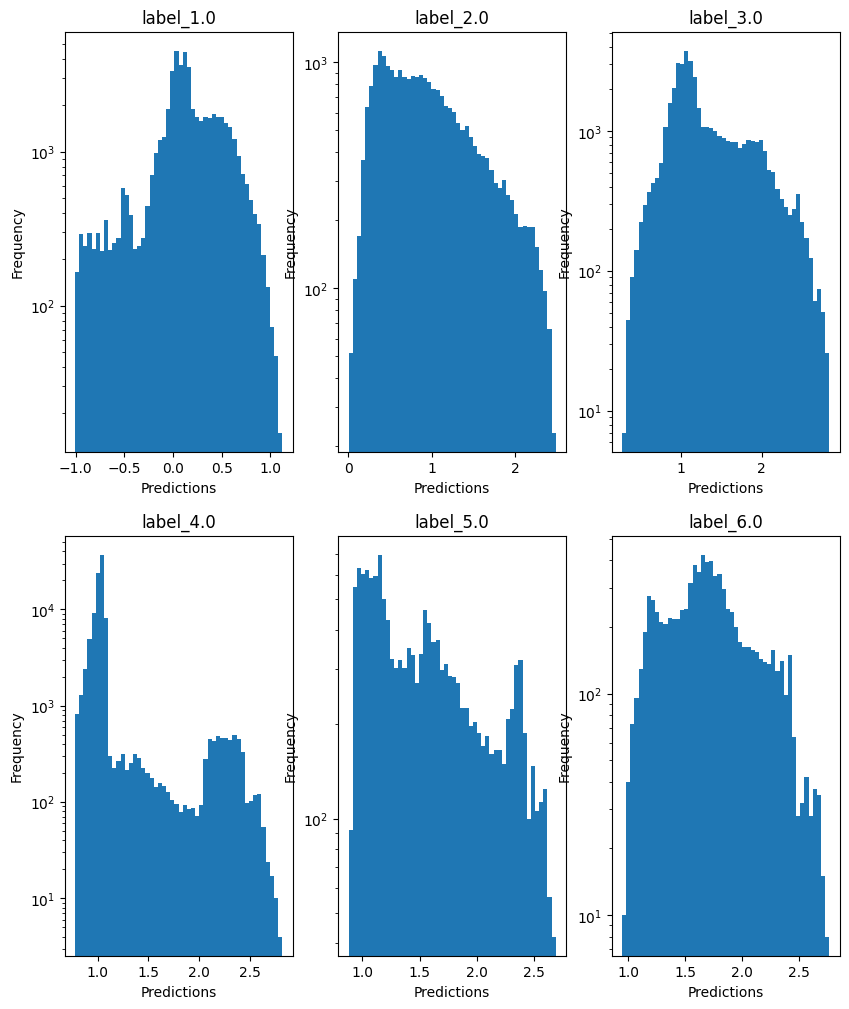

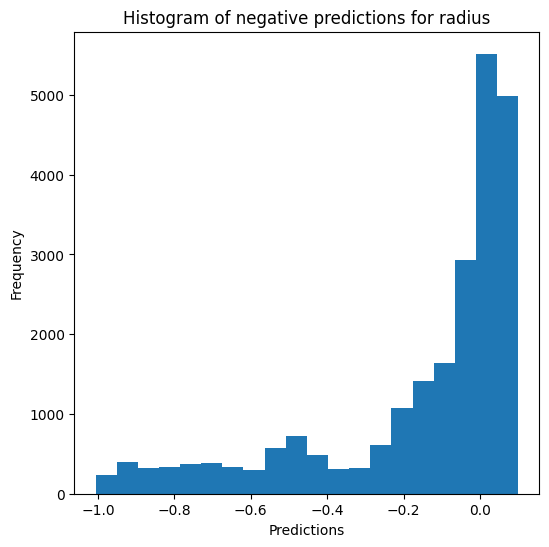

Saving predictions and results...


In [21]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name,
                                      hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400)

Avec batch_size=auto (200):

plus de 30 minutes pour entrainer un seul split de Kfold avec les paramètres par défaut (1 hidden layer de taille 100)

plus de 15 minutes pour entrainer un seul split de Kfold avec les 1 hidden layer de taille 10

- et max_iter=20, hidden_layer_sizes=(100, 50, 25): ~5 minutes par fold (plutôt bon résultats)
- et max_iter=20, hidden_layer_sizes=(100, 100, 100): ~5 minutes par fold

Avec batch_size=400:


Avec learning_rate= :


hidden_layer_sizes = (100, 100), max_iter=20, batch_size=200 => 17 min pour 2 splits et min_loss de 2.1
RMSE = RVE :  0.984867927459382
RMSE :  2.5335132759292107
MAE :  0.7276983504493552
MedAE :  0.3034009994265745
CORR :  0.9927285673947535
MAX_ER :  169.74348568157313
Percentiles : 75th percentile :  0.5113604728134682 90th percentile :  1.1025928446049704 95th percentile :  2.1347654852226015 99th percentile :  9.897101952249908)

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=400 => 7 min pour 2 splits et min_loss de 2.2
RVE :  0.9797171492755655
RMSE :  2.983208723004754
MAE :  0.9125599339275378
MedAE :  0.43124518658659683
CORR :  0.9920536596906272
MAX_ER :  170.53076478793002
Percentiles : 75th percentile :  0.675744507049632 90th percentile :  1.2421052024331438 95th percentile :  2.441733387262636 99th percentile :  11.925724226452427

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=800 => 3 min pour 2 splits et min_loss de 2.3 et 2.7

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=1600 => 3 min 30 pour 2 splits et min_loss de 7.8 et 3.8

=> batch_size plus grand == plus rapide mais moins bon